In [1]:
import importlib
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# import deeptime
import scipy
import pandas as pd
import os
from matplotlib.lines import Line2D
import matplotlib.ticker as mtick
from pygam import LinearGAM, s
import scipy.stats as st
from scipy.interpolate import pchip_interpolate


import iMSM.extensions.npc.npc
importlib.reload(iMSM.extensions.npc.npc)
from iMSM.extensions.npc.npc import run
# --
import raveh_2025.show_transport_stats_v3
importlib.reload(raveh_2025.show_transport_stats_v3)
from raveh_2025.show_transport_stats_v3 import read_df, calc_filtered_transport_stats
# --
import iMSM.extensions.npc.npc_utils
importlib.reload(iMSM.extensions.npc.npc_utils)
from utils import radius_a_to_kda, amount_to_concentration

In [2]:
# Defines a utility function to send push notifications 
# via ntfy.sh upon script completion

import requests
def send_notification():
    # Replace with the exact topic name you chose in the app
    topic = "huji_cluster_notifications_abcdefg123456" 
    
    requests.post(
        f"https://ntfy.sh/{topic}",
        data="✅ Your Python script has finished running!".encode(encoding='utf-8'),
        headers={
            "Title": "Python Alert",
            "Priority": "high",
            "Tags": "snake"
        }
    )

In [ ]:
# Runss for various site-radius combinations and sim/time-based data subsets

for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset in [1/30, 2 / 30, 5 / 30, 10 / 30, 15 / 30, 20 / 30, 25 / 30, 1.0]: # 
            print (f"~~~~~~~ subset {subset} ~~~~~~~")
    # for radius in [22]:
            
            checkpoint_path = f"data/ntr_variants/{sites}_{radius}_more/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 70000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants/{sites}_{10}_more/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = 50
            params['SOFT_SCALE_NM'] = 5
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [320]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "simulation" 

            params['STATE_CHOICE_METHOD'] = "distance_clustering_z" 
            params['CLUSTERING_Z_STRENGTH'] = np.sqrt(458) / 10
            params['N_CLUSTERS'] = [320]
            
            
            run(checkpoint_path, params_override=params, start_stage=5, end_stage=8)
            
send_notification()

In [ ]:
# Executes the pipeline for 4 sites and a 26 nm radius to compare 
# timescales across different window sizes

for sites in [4]:
    for radius in [26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        # for subset in [1]: # 
        for window_size_steps in [5, 10, 25, 50, 100, 200]: 
            print (f"~~~~~~~ window size {window_size_steps} steps ~~~~~~~")
            subset = 1
            
            checkpoint_path = f"data/ntr_variants_4_26_timescales/window_{window_size_steps}_steps/"
            
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 70000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants/{sites}_{10}_more/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['STATE_CHOICE_METHOD'] = "distance" # options: "prominent", "distance", "nuc_cyt_treshold"
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = window_size_steps
            params['SOFT_SCALE_NM'] = 5
            
            params['CUSTOM_CATEGORIZED_PATH'] = f"data/ntr_variants/{sites}_{radius}_more/3_categorized.pickle"
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [160]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "simulation" 
            
            
            run(checkpoint_path, params_override=params, start_stage=4, end_stage=8)
            
send_notification()

In [ ]:
# Runs the pipeline for low simulation time subsets by proportionally 
# decreasing the window sizes across all combinations

for sites in [2,4,6]:
    for radius in [10, 14, 18, 22, 26]:
        print (f"~~~~~~~ Running for {sites} sites and radius {radius} ~~~~~~~")
        for subset, window in [(2/60, 10), (4/60, 20), (8/60, 40)]: # 
            print (f"~~~~~~~ subset {subset} ~~~~~~~")
    # for radius in [22]:
            
            checkpoint_path = f"data/ntr_variants_low_time_subsets/{sites}_{radius}_more/"
            params = {}
            params['LOAD_MD_KAP_SITES'] = sites
            params['LOAD_MD_KAP_RADIUS'] = radius
            params['LOAD_MD_KAP_AMOUNT'] = 100
            params['LOAD_MD_BASE_PATH'] = f"/cs/usr/roi.eliasian/LabFolder/NpcTransportExperiment/HS-AFM-Dataset/dataset/full_variants/{sites}_sites_small"
            params['LOAD_MD_SIMS_RANGE'] = range(1, 31)
            params['LOAD_MD_START_TIME_NS'] = 10000
            params['LOAD_MD_END_TIME_NS'] = 70000
            params['LOAD_MD_STEP_NS'] = 100
            params['CUSTOM_FG_COORDS_PATH'] = f"data/ntr_variants/{sites}_{10}_more/2_single_sim_fg_coords/"
            params['TM_PRIOR'] = 0.0001
            params['DISTANCE_STATE_THRESHOLD_NM'] = 10
            params['WINDOW_SIZE_STEPS'] = window
            params['SOFT_SCALE_NM'] = 5
            
            
            params['MODE'] = "subset"
            params['N_CLUSTERS'] = [320]
            params['DATA_SUBSET'] = subset
            params['DATA_SUBSET_INDEX'] = 0
            params['DATA_SUBSET_MODE'] = "time" 

            params['STATE_CHOICE_METHOD'] = "distance_clustering_z" 
            params['CLUSTERING_Z_STRENGTH'] = np.sqrt(458) / 10
            params['N_CLUSTERS'] = [320]
            params['CUSTOM_KAP_COORDS_PATH'] = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            params['CUSTOM_CATEGORIZED_PATH'] = f"data/ntr_variants/{sites}_{radius}_more/3_categorized.pickle"


            
            
            run(checkpoint_path, params_override=params, start_stage=4, end_stage=8)
            
send_notification()

In [4]:
# Defines helper functions to collect empirical and modeled permeabilities, 
# confidence intervals, and plot power-law fits

n_sites = [2, 4, 6]
radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]

def poisson_confidence_interval(count, alpha=0.05):
    lower = scipy.stats.chi2.ppf(alpha/2, 2*count) / 2
    upper = scipy.stats.chi2.ppf(1-alpha/2, 2*(count+1)) / 2
    
    return lower, upper

# Collect data
def collect_perms_md():
    results = []
    for sites in n_sites:
        for radius in radii:
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=None)
            
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'total_transports': total_full_transports,
                'n_trajs': n_trajs,
                'permeability': permeability,
                'lower_permeability': lower_permeability if lower_permeability >=0 else 0,
                'upper_permeability': upper_permeability if upper_permeability >=0 else 0
            })
    return results

def collect_perms_md_single_type(kap_coords_folder, n_sims, start_time, end_time, shorten_time_to_us, step_ns=100):
    """
    Count transport events from raw 3D kap coordinates.
    
    kap_coords_folder: path containing subfolders 1, 2, ..., n_sims,
                       each with a file 'start_time-end_time.pickle' of shape (kap_amount, 3, n_frames).
    step_ns: time per frame in nanoseconds (default 100 ns).
    """
    # Load and concatenate raw 3D coordinates across all simulations
    all_coords = []
    for sim_idx in range(1, n_sims + 1):
        path = os.path.join(kap_coords_folder, str(sim_idx), f"{start_time}-{end_time}.pickle")
        with open(path, "rb") as f:
            coords = pickle.load(f)  # shape: (kap_amount, 3, n_frames)
        all_coords.append(coords)

    all_coords = np.concatenate(all_coords, axis=0)  # shape: (kap_amount * n_sims, 3, n_frames)

    _, _, n_frames = all_coords.shape
    time_us = n_frames * step_ns / 1000  # convert ns → µs

    if shorten_time_to_us is not None:
        if shorten_time_to_us > time_us:
            raise ValueError(f"shorten_time_to {shorten_time_to_us} µs is greater than trajectory length {time_us} µs")
        n_frames_to_use = int(shorten_time_to_us * 1000 / step_ns)
        time_us = shorten_time_to_us
        all_coords = all_coords[:, :, :n_frames_to_use]

    # Count transport events across all kap trajectories
    # z-axis is index 2 in the (kap_amount, 3, n_frames) array
    total_full_transports = 0
    n_trajs = all_coords.shape[0]
    for i in range(n_trajs):
        z = all_coords[i, 2, :]  # shape: (n_frames,)
        last_side = None

        for z_val in z:
            if z_val >= 10:
                current_side = 1   # cytoplasmic side (top)
            elif z_val <= -10:
                current_side = 0   # nuclear side (bottom)
            else:
                continue           # inside the channel, not yet committed

            if last_side is None:
                last_side = current_side   # initialise, don't count
            elif last_side != current_side:
                total_full_transports += 1
                last_side = current_side

    concentration_M = amount_to_concentration(100, box_side_a=800)
    concentration_uM = concentration_M * 1e6
            
    time_s = time_us * 1e-6

    lower, upper = poisson_confidence_interval(total_full_transports)
    rate = total_full_transports / (time_s * n_sims)
    lower_rate = lower / (time_s * n_sims)
    upper_rate = upper / (time_s * n_sims)
    permeability = rate / concentration_uM
    lower_permeability = lower_rate / concentration_uM
    upper_permeability = upper_rate / concentration_uM
    return n_trajs, total_full_transports, permeability, lower_permeability, upper_permeability

def collect_perms_msm_bootstrap(n_clusters=640):
    results = []
    for sites in n_sites:
        for radius in radii:
            with open(f"data/ntr_variants/{sites}_{radius}/7_permeabilities_bootstrap.pickle", "rb") as f:
                bootstrapped_perms = pickle.load(f)
            n_bootstraps = len(bootstrapped_perms)
            perms = []
            for b in range(n_bootstraps):
                perms.append(bootstrapped_perms[b][n_clusters])
            perms = np.array(perms)
            meadian_perm = np.median(perms)
            lower = np.percentile(perms, 5)
            upper = np.percentile(perms, 95)
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'median_permeability': meadian_perm,
                'lower_permeability': lower,
                'upper_permeability': upper
            })
    return results

def collect_perms_msm(n_clusters=160):
    results = []
    for sites in n_sites:
        for radius in radii:
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/1.00fraction_simulations/0index/7_permeabilities.pickle", "rb") as f:
                perms_dict = pickle.load(f)
            permeability = perms_dict[n_clusters]
            results.append({
                'sites': sites,
                'radius': radius,
                'kda': radius_a_to_kda(radius),
                'permeability': permeability
            })
    return results

def weighted_power_law_fit(x, y, y_err=None):
    weights = None
    if y_err is not None:
        log_y_err = y_err / y
        weights = 1 / (log_y_err ** 2)
        weights = np.nan_to_num(weights, nan=1.0, posinf=1.0, neginf=1.0)
        weights = weights / np.mean(weights)
        weights = np.clip(weights, 0.1, 10)

    coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
    poly = np.poly1d(coeffs)
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = 10 ** poly(np.log10(x_fit))
    y_fit_per_original_x = 10 ** poly(np.log10(x))
    slope, intercept = coeffs
    return x_fit, y_fit, slope, intercept, y_fit_per_original_x

def plot_permeability_dataset(ax, data, x_col, y_col, color, label, marker, low_col, high_col):
    if data.empty:
        return

    data = data.sort_values(x_col)

    
    if low_col is not None and high_col is not None:
        y_err_lower = data[y_col] - data[low_col]
        y_err_upper = data[high_col] - data[y_col]
        y_err = (y_err_lower + y_err_upper) / 2
        
        x_fit, y_fit, slope, intercept, _ = weighted_power_law_fit(data[x_col], data[y_col], y_err=None)
        ax.plot(x_fit, y_fit, linestyle='--', color=color, alpha=0.7)
        
        x_fit_lo, y_fit_lo, _, _, _ = weighted_power_law_fit(data[x_col], data[low_col], y_err=None)
        x_fit_hi, y_fit_hi, _, _, _ = weighted_power_law_fit(data[x_col], data[high_col], y_err=None)
        
        ax.fill_between(x_fit, y_fit_lo, y_fit_hi, color=color, alpha=0.1)
        ax.errorbar(
            data[x_col],
            data[y_col],
            yerr=[y_err_lower, y_err_upper],
            marker=marker,
            markersize=8,
            linestyle='None',
            # label=fr'{label}: $y={10**intercept:.2f}x^{{{slope:.2f}}}$',
            label = fr'{label}: $y \propto x^{{{slope:.2f}}}$',
            color=color,
            linewidth=2,
        )
    else:
        x_fit, y_fit, slope, intercept, _ = weighted_power_law_fit(data[x_col], data[y_col], None)
        ax.plot(x_fit, y_fit, linestyle='--', color=color, alpha=0.7)
        ax.plot(
            data[x_col],
            data[y_col],
            marker=marker,
            markersize=8,
            linestyle='None',
            # label=fr'{label}: $y={10**intercept:.2f}x^{{{slope:.2f}}}$',
            label = fr'{label}: $y \propto x^{{{slope:.2f}}}$',
            color=color,
            linewidth=2
        )


In [5]:
# Collects empirical and modeled permeabilities into Pandas DataFrames 
# to prepare for comparison plotting

results_emp = collect_perms_md()
df_results_emp = pd.DataFrame(results_emp)
results_tm = collect_perms_msm(n_clusters=320)
df_results_tm = pd.DataFrame(results_tm)

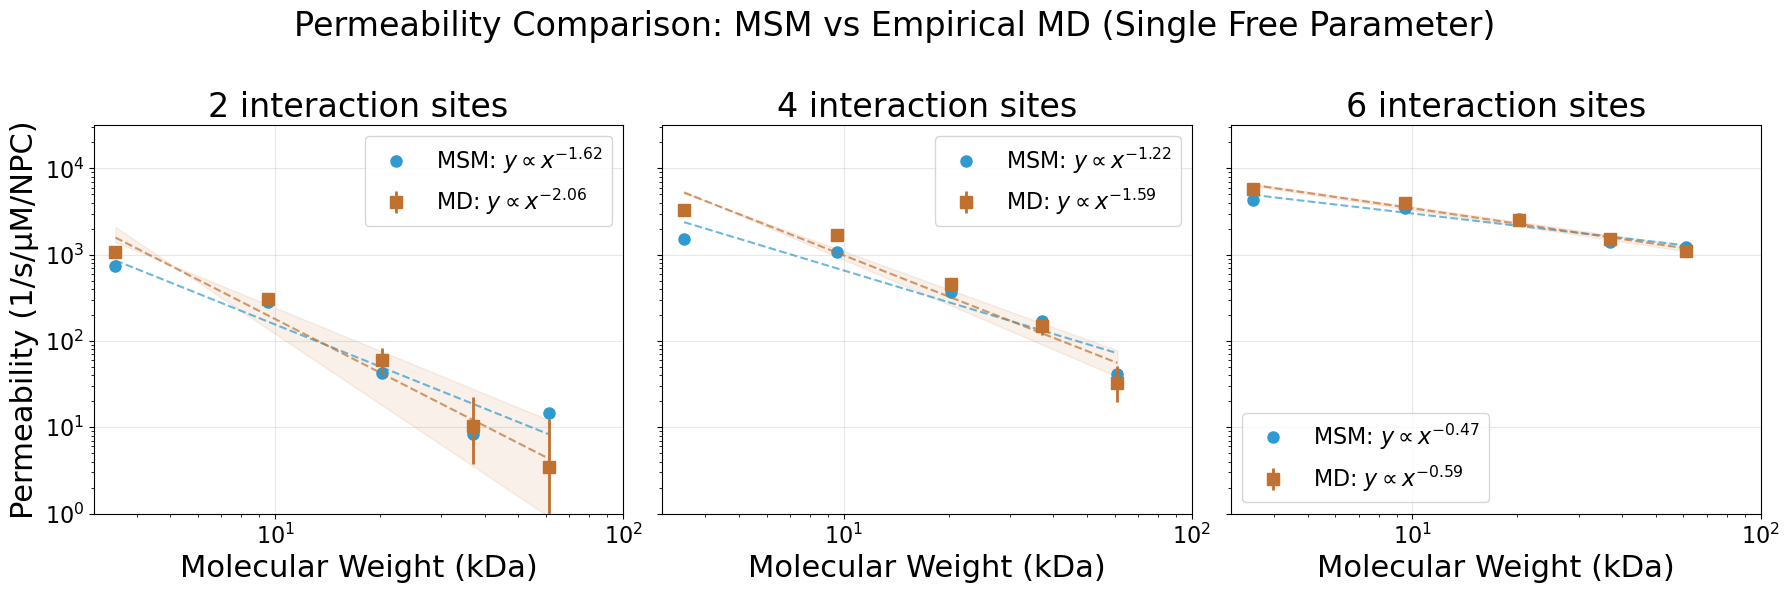

In [6]:
# print(df_results_emp.to_string(index=False))


colors = {"MSM": "#2f9acf", "Empirical": "#c0702f"}
site_values = [2, 4, 6]

fig, axes = plt.subplots(1, len(site_values), figsize=(18, 6), sharey=True)
fig.suptitle('Permeability Comparison: MSM vs Empirical MD (Single Free Parameter)', fontsize=24)

for ax, site in zip(axes, site_values):
    msm_site = df_results_tm[df_results_tm['sites'] == site]
    emp_site = df_results_emp[df_results_emp['sites'] == site]
    # if site == 2 and 'total_transports' in emp_site:
    #     emp_site = emp_site[emp_site['total_transports'] > 0]
    free_coeff = 1 # single free parameter
    msm_site.loc[:, 'permeability'] = msm_site['permeability'] / free_coeff
    # emp_site.loc[:, 'lower_permeability'] = emp_site['lower_permeability'] * free_coeff
    # emp_site.loc[:, 'upper_permeability'] = emp_site['upper_permeability'] * free_coeff

    ax.set_title(f'{site} interaction sites', fontsize=24)
    plot_permeability_dataset(
        ax,
        msm_site,
        'kda',
        'permeability',
        colors['MSM'],
        'MSM',
        'o',
        None,
        None
    )
    plot_permeability_dataset(
        ax,
        emp_site,
        'kda',
        'permeability',
        colors['Empirical'],
        'MD',
        's',
        'lower_permeability',
        'upper_permeability'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([10**1, 10**2])
    ax.set_xticklabels([r'$10^1$', r'$10^2$'])
    ax.set_ylim(1, 10**4.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Molecular Weight (kDa)', fontsize=22)
    ax.legend(fontsize=16)
    
    # set tick font size
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

axes[0].set_ylabel('Permeability (1/s/µM/NPC)', fontsize=22)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# # Print summary statistics
# print("\nSummary Statistics:")
# print(df_results_emp.to_string(index=False))
# print(df_results_tm.to_string(index=False))

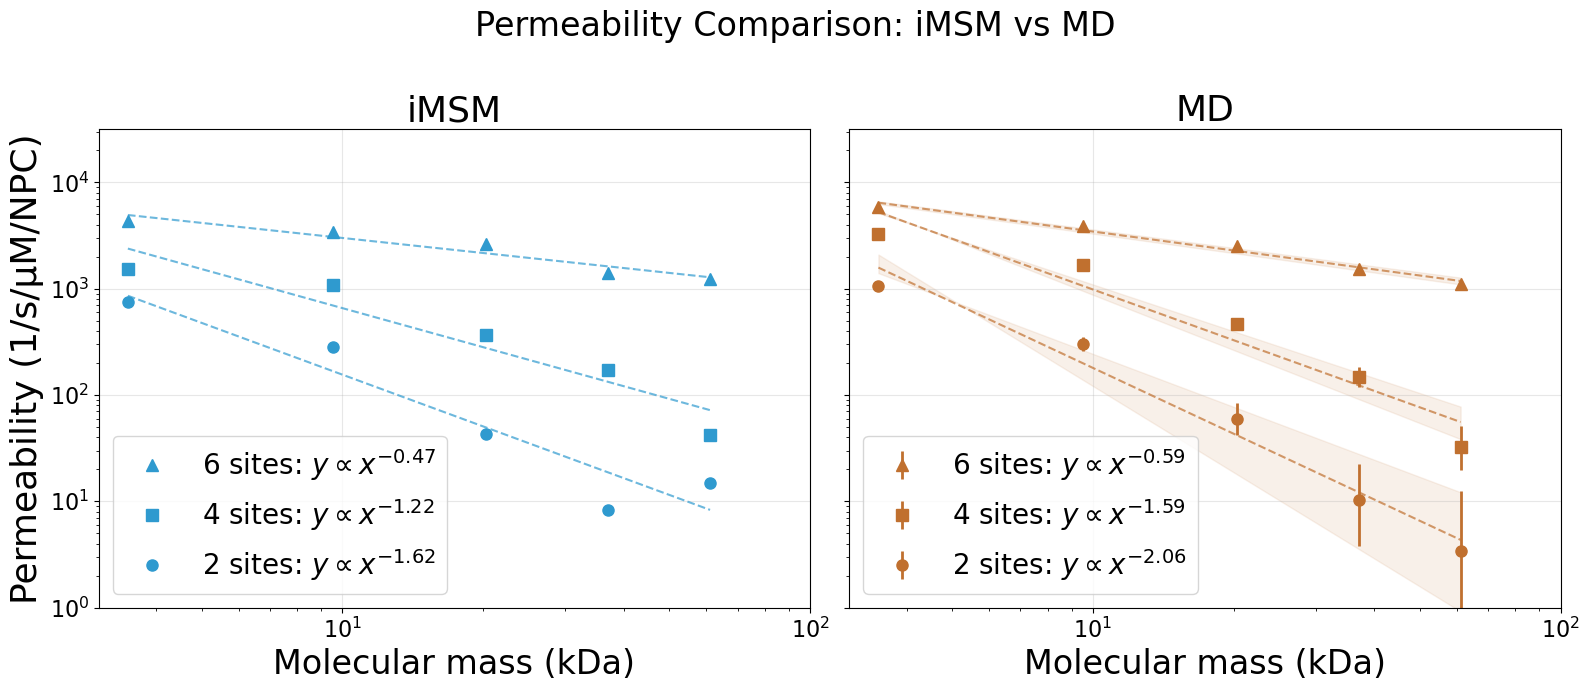

In [7]:
# Keep your original method colors
colors = {"MSM": "#2f9acf", "Empirical": "#c0702f"}
site_values = [2, 4, 6]

# Differentiate the site amounts by marker shape
site_markers = {2: 'o', 4: 's', 6: '^'}

# Create 1 row, 2 columns (one for MSM, one for MD)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Permeability Comparison: iMSM vs MD', fontsize=24)

axes[0].set_title('iMSM', fontsize=26)
axes[1].set_title('MD', fontsize=26)

for site in site_values:
    # Use .copy() to prevent Pandas SettingWithCopyWarning
    msm_site = df_results_tm[df_results_tm['sites'] == site].copy()
    emp_site = df_results_emp[df_results_emp['sites'] == site].copy()
    
    free_coeff = 1 # single free parameter
    msm_site['permeability'] = msm_site['permeability'] / free_coeff

    # 1. Plot MSM data
    plot_permeability_dataset(
        ax=axes[0],
        data=msm_site,
        x_col='kda',
        y_col='permeability',
        color=colors['MSM'],         # Lock to MSM color
        label=f'{site} sites',
        marker=site_markers[site],   # Differentiate by marker shape
        low_col=None,
        high_col=None
    )
    
    # 2. Plot MD data
    plot_permeability_dataset(
        ax=axes[1],
        data=emp_site,
        x_col='kda',
        y_col='permeability',
        color=colors['Empirical'],   # Lock to MD color
        label=f'{site} sites',
        marker=site_markers[site],   # Differentiate by marker shape
        low_col='lower_permeability',
        high_col='upper_permeability'
    )

# Format both axes
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([10**1, 10**2])
    ax.set_xticklabels([r'$10^1$', r'$10^2$'])
    ax.set_ylim(1, 10**4.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Molecular mass (kDa)', fontsize=24)
    
    # Grab the current legend handles and labels, then reverse them
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=20)
    
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

# Only the leftmost subplot needs the Y-axis label
axes[0].set_ylabel('Permeability (1/s/µM/NPC)', fontsize=26)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [4]:
# convergence stuff params

radii = [10, 14, 18, 22, 26]
kdas = [radius_a_to_kda(r) for r in radii]
sites_list = [2, 4, 6]
n_clusters = 320
# subsets = [0.04, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1]
subsets = [2/60, 4/60, 8/60, 10/60, 15/60, 20/60, 25/60, 30/60, 40/60, 50/60, 60/60]
total_simulation_times = [int(60 * subset) * 30 for subset in subsets]

sims_subsets = [1/30, 2 / 30, 5 / 30, 10 / 30, 15 / 30, 20 / 30, 25 / 30, 1.0]
sims_total_simulation_times = [subset * 30  * 60 for subset in sims_subsets]

In [23]:
# save convergence data
sites_to_fitted_perms = {}
sites_to_fitted_perms_lo = {}
sites_to_fitted_perms_hi = {}

for sites in sites_list:
    sites_perms = []
    sites_perms_lower = []
    sites_perms_upper = []
    sites_errs = []
    for radius in radii:
        kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
        results = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=None)
        perms = results[2]
        perms_lower = results[3]
        perms_upper = results[4]
        y_err_lower = perms - perms_lower
        y_err_upper = perms_upper - perms
        y_err = (y_err_lower + y_err_upper) / 2
        sites_perms.append(perms)
        sites_perms_lower.append(perms_lower)
        sites_perms_upper.append(perms_upper)
        sites_errs.append(y_err)
    sites_perms = np.array(sites_perms)
    sites_perms_lower = np.array(sites_perms_lower)
    sites_perms_upper = np.array(sites_perms_upper)
    sites_errs = np.array(sites_errs)
    _, _, slope, intercept, y_fit = weighted_power_law_fit(kdas, sites_perms, y_err=None) #sites_errs)
    _, _, _, _, y_fit_lo = weighted_power_law_fit(kdas, sites_perms_lower, y_err=None) #sites_errs)
    _, _, _, _, y_fit_hi = weighted_power_law_fit(kdas, sites_perms_upper, y_err=None) #sites_errs)
    sites_to_fitted_perms[sites] = y_fit
    sites_to_fitted_perms_lo[sites] = y_fit_lo
    sites_to_fitted_perms_hi[sites] = y_fit_hi

perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
lower_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))
upper_perms_all_md = np.zeros((len(radii), len(sites_list), len(subsets)))

perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))
lower_perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))
upper_perms_all_md_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))

perms_all_msm = np.zeros((len(radii), len(sites_list), len(subsets)))
perms_all_msm_with_init_time = np.ones((len(radii), len(sites_list), len(subsets))) * -1  # Set default to -1 so we can easily filter them out if needed
perms_all_msm_sim_subset = np.zeros((len(radii), len(sites_list), len(sims_subsets)))



for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):

        # Collect MSM permeabilities (time subset)
        for conf_name, target_arr in [
            ("ntr_variants", perms_all_msm), 
            ("ntr_variants_with_init_time", perms_all_msm_with_init_time)
        ]:
            if conf_name == "ntr_variants_with_init_time" and sites == 6:
                continue # Skip 6 sites variant for init time
            
            low_time_folder = "ntr_variants_low_time_subsets" if conf_name == "ntr_variants" else "ntr_variants_with_init_time_low_time_subsets"
            for k, subset in enumerate(subsets):
                path = f"data/{conf_name}/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction/0index/7_permeabilities.pickle"
                if subset in [2/60, 4/60, 8/60]:
                    path = f"data/{low_time_folder}/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction/0index/7_permeabilities.pickle"
                with open(path, "rb") as f:
                    perms = pickle.load(f)
                    target_arr[i, j, k] = perms[n_clusters]
                
        # Collect MSM permeabilities (sim subset)
        for k, subset in enumerate(sims_subsets):
            with open(f"data/ntr_variants/{sites}_{radius}_more/7_permeabilities_subsets/{subset:.2f}fraction_simulations/{0}index/7_permeabilities.pickle", "rb") as f:
                perms = pickle.load(f)
                perms_all_msm_sim_subset[i, j, k] = perms[n_clusters]
        
        # Collect MD permeabilities (time subset)
        for k, subset in enumerate(subsets):
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            results = collect_perms_md_single_type(kap_coords_folder, n_sims=30, start_time=10, end_time=70, shorten_time_to_us=int(subset * 60))
            perms_all_md[i, j, k] = results[2]
            lower_perms_all_md[i, j, k] = results[3]
            upper_perms_all_md[i, j, k] = results[4]
            
        # Collect MD permeabilities (sim subset)
        for k, subset in enumerate(sims_subsets):
            kap_coords_folder = f"data/ntr_variants/{sites}_{radius}_more/1_single_sim_kap_coords/"
            results = collect_perms_md_single_type(kap_coords_folder, n_sims=int(30*subset), start_time=10, end_time=70, shorten_time_to_us=None)
            perms_all_md_sim_subset[i, j, k] = results[2]
            lower_perms_all_md_sim_subset[i, j, k] = results[3]
            upper_perms_all_md_sim_subset[i, j, k] = results[4]
    
# save convergence data
# md time subset
with open("data/convergence/perms_all_md.pickle", "wb") as f:
    pickle.dump(perms_all_md, f)
with open("data/convergence/lower_perms_all_md.pickle", "wb") as f:
    pickle.dump(lower_perms_all_md, f)
with open("data/convergence/upper_perms_all_md.pickle", "wb") as f:
    pickle.dump(upper_perms_all_md, f)
    
# md sim subset
with open("data/convergence/perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(perms_all_md_sim_subset, f)
with open("data/convergence/lower_perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(lower_perms_all_md_sim_subset, f)
with open("data/convergence/upper_perms_all_md_sim_subset.pickle", "wb") as f:
    pickle.dump(upper_perms_all_md_sim_subset, f)

# msm time subset
with open("data/convergence/perms_all_msm.pickle", "wb") as f:
    pickle.dump(perms_all_msm, f)

with open("data/convergence/perms_all_msm_with_init_time.pickle", "wb") as f:
    pickle.dump(perms_all_msm_with_init_time, f)

# msm sim subset
with open("data/convergence/perms_all_msm_sim_subset.pickle", "wb") as f:
    pickle.dump(perms_all_msm_sim_subset, f)

# ideal fits
with open("data/convergence/sites_to_fitted_perms.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms, f)
with open("data/convergence/sites_to_fitted_perms_lo.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms_lo, f)
with open("data/convergence/sites_to_fitted_perms_hi.pickle", "wb") as f:
    pickle.dump(sites_to_fitted_perms_hi, f)

In [2]:
# load convergence data
# md time subset
with open("data/convergence/perms_all_md.pickle", "rb") as f:
    perms_all_md = pickle.load(f)
with open("data/convergence/lower_perms_all_md.pickle", "rb") as f:
    lower_perms_all_md = pickle.load(f)
with open("data/convergence/upper_perms_all_md.pickle", "rb") as f:
    upper_perms_all_md = pickle.load(f)
    
# md sim subset
with open("data/convergence/perms_all_md_sim_subset.pickle", "rb") as f:
    perms_all_md_sim_subset = pickle.load(f)
with open("data/convergence/lower_perms_all_md_sim_subset.pickle", "rb") as f:
    lower_perms_all_md_sim_subset = pickle.load(f)
with open("data/convergence/upper_perms_all_md_sim_subset.pickle", "rb") as f:
    upper_perms_all_md_sim_subset = pickle.load(f)
    
# msm time subset
with open("data/convergence/perms_all_msm.pickle", "rb") as f:
    perms_all_msm = pickle.load(f)
    
with open("data/convergence/perms_all_msm_with_init_time.pickle", "rb") as f:
    perms_all_msm_with_init_time = pickle.load(f)
    
# msm sim subset
with open("data/convergence/perms_all_msm_sim_subset.pickle", "rb") as f:
    perms_all_msm_sim_subset = pickle.load(f)

# ideal fits
with open("data/convergence/sites_to_fitted_perms.pickle", "rb") as f:
    sites_to_fitted_perms = pickle.load(f)
with open("data/convergence/sites_to_fitted_perms_lo.pickle", "rb") as f:
    sites_to_fitted_perms_lo = pickle.load(f)
with open("data/convergence/sites_to_fitted_perms_hi.pickle", "rb") as f:
    sites_to_fitted_perms_hi = pickle.load(f)
    
print(perms_all_msm_with_init_time[:, :, -1])

[[ 5.97838308e+02  1.85842943e+03 -1.00000000e+00]
 [ 2.00725178e+02  1.42638918e+03 -1.00000000e+00]
 [ 3.69589217e+01  4.42602615e+02 -1.00000000e+00]
 [ 9.62000854e+00  1.63951257e+02 -1.00000000e+00]
 [ 8.96223017e+00  4.03094802e+01 -1.00000000e+00]]


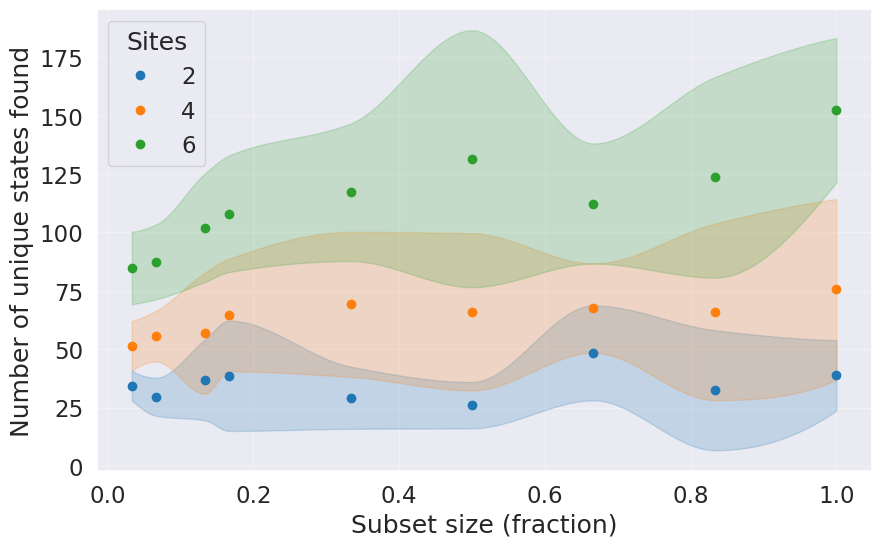

In [17]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Double the size of all fonts and elements
sns.set_theme(font_scale=1.5)

sites_list = [2, 4, 6]
radii = [10, 14, 18, 22, 26]
subsets = [2/60, 4/60, 8/60, 1/30, 2/30, 5/30, 10/30, 15/30, 20/30, 25/30, 1.0]

data = []

for radius in radii:
    for sites in sites_list:
        for subset in subsets:
            if subset in [2/60, 4/60, 8/60]:
                path = f"data/ntr_variants_low_time_subsets/{sites}_{radius}_more/6_transition_matrices_subsets/{subset:.2f}fraction/0index/320clusters.pickle"
            else:
                path = f"data/ntr_variants/{sites}_{radius}_more/6_transition_matrices_subsets/{subset:.2f}fraction/0index/320clusters.pickle"
            
            if os.path.exists(path):
                with open(path, "rb") as f:
                    tm = pickle.load(f)
                    data.append({
                        "radius": radius,
                        "sites": sites,
                        "subset": subset,
                        "states": tm.shape[0]
                    })

df_states = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))

# Extract the colors we need from seaborn's tab10 palette
colors = sns.color_palette("tab10", n_colors=len(sites_list))

for i, sites in enumerate(sites_list):
    df_sub = df_states[df_states["sites"] == sites]
    
    # Calculate means and group the data
    grouped = df_sub.groupby("subset")["states"]
    x: np.ndarray = np.sort(list(grouped.groups.keys()))
    means: np.ndarray = np.array([grouped.get_group(k).mean() for k in x])
    
    ci_lower: list[float] = []
    ci_upper: list[float] = []
    
    # Calculate 95% Confidence Intervals manually
    for k in x:
        data_points: np.ndarray = grouped.get_group(k).values
        if len(data_points) > 1:
            interval = st.t.interval(
                0.95, 
                df=len(data_points)-1, 
                loc=np.mean(data_points), 
                scale=st.sem(data_points)
            )
            ci_lower.append(interval[0])
            ci_upper.append(interval[1])
        else:
            ci_lower.append(data_points[0])
            ci_upper.append(data_points[0])
            
    ci_lower_arr: np.ndarray = np.array(ci_lower)
    ci_upper_arr: np.ndarray = np.array(ci_upper)

    # Generate a denser set of x values for smooth interpolation
    x_smooth: np.ndarray = np.linspace(x.min(), x.max(), 300)

    # Use PCHIP interpolation to avoid unnatural wiggles/overshooting
    y_lower_smooth: np.ndarray = pchip_interpolate(x, ci_lower_arr, x_smooth)
    y_upper_smooth: np.ndarray = pchip_interpolate(x, ci_upper_arr, x_smooth)

    # Plot smoothed CI bounds
    plt.fill_between(x_smooth, y_lower_smooth, y_upper_smooth, alpha=0.2, color=colors[i])
    
    # Plot markers for the means (This matches the marker="o", lw=0 from seaborn)
    plt.plot(x, means, 'o', color=colors[i], label=f"{sites}")

plt.title("")
plt.xlabel("Subset size (fraction)")
plt.ylabel("Number of unique states found")

# Ensures the legend title is appropriately named
plt.legend(title="Sites")
plt.grid(True, alpha=0.3)
plt.show()


In [27]:
# put shared functions here

# Unified styling config mapping 'method' to visual parameters
STYLE = {
    'md_time':  {'color': '#c0702f', 'marker': 'o', 'ms': 6, 'lw': 4.0, 'alpha': 0.6, 'zorder': 2},
    'msm_time': {'color': '#2f9acf', 'marker': 'o', 'ms': 6, 'lw': 4.0, 'alpha': 0.6, 'zorder': 4},
    'md_sim':   {'color': '#a0522d', 'marker': 's', 'ms': 6, 'lw': 4.0, 'alpha': 0.6, 'zorder': 2},
    'msm_sim':  {'color': '#2166ac', 'marker': 's', 'ms': 6, 'lw': 4.0, 'alpha': 0.6, 'zorder': 4},
}

STAR_Y_PERM = 10**-0.8

def get_gam_curve(x, y, n_points=100):
    """Fits a GAM in log10 space and returns a smooth curve."""
    valid = (x > 0) & (y > 0) & ~np.isnan(x) & ~np.isnan(y)
    x_val, y_val = x[valid], y[valid]
    
    if len(x_val) < 4: 
        return x_val, y_val
        
    x_log = np.log10(x_val).reshape(-1, 1)
    y_log = np.log10(y_val)
    
    n_splines = min(10, len(x_val))
    gam = LinearGAM(s(0, n_splines=n_splines)).gridsearch(x_log, y_log, progress=False)
    
    x_grid = np.linspace(x_log.min(), x_log.max(), n_points).reshape(-1, 1)
    return 10**x_grid.flatten(), 10**gam.predict(x_grid)

def plot_target_line(ax, x, target_val, lo_val=None, hi_val=None):
    """Plots the horizontal target regression line and optional confidence bands."""
    line, = ax.plot(x, [target_val] * len(x), color='red', linestyle='--', alpha=0.8, zorder=1, label='Fitted Target', lw=3.0)
    if lo_val is not None and hi_val is not None:
        ax.fill_between(x, lo_val, hi_val, color='red', alpha=0.15, zorder=1)
    return line

def plot_series(ax, x, y, style, star_y, y_lower=None, y_upper=None, gam_ls='-'):
    """Plots the scatter data, GAM curve, zero-value stars, and optional error bars."""
    valid = y > 0
    y_plot = np.where(valid, y, np.nan)
    
    # Scatter
    ax.plot(x, y_plot, marker=style['marker'], markersize=style['ms'], color=style['color'], 
            linestyle='None', alpha=style['alpha'], zorder=style['zorder'])
    
    # GAM Line
    x_gam, y_gam = get_gam_curve(x, y_plot)
    ax.plot(x_gam, y_gam, color=style['color'], linestyle=gam_ls, linewidth=style['lw'], 
            alpha=style['alpha'], zorder=style['zorder'], label=style.get('label', None))
    
    # Stars for zeros
    zeros = ~valid
    if np.any(zeros):
        ax.plot(x[zeros], [star_y] * np.sum(zeros), marker='*', markersize=12, 
                color=style['color'], linestyle='None', zorder=style['zorder'] + 1)
        
    # Error bars (only plotted for valid > 0 points)
    if y_lower is not None and y_upper is not None:
        y_err = [(y - y_lower)[valid], (y_upper - y)[valid]]
        ax.errorbar(x[valid], y[valid], yerr=y_err, fmt='none', ecolor=style['color'], 
                    alpha=0.9, elinewidth=2, capsize=3, zorder=style['zorder'])

def get_ratio(y_num, y_den):
    """Calculates ratio where both arrays are strictly positive, returning NaNs otherwise."""
    ratio = np.full_like(y_num, np.nan, dtype=float)
    valid = (y_num > 0) & (y_den > 0)
    ratio[valid] = y_num[valid] / y_den[valid]
    return ratio

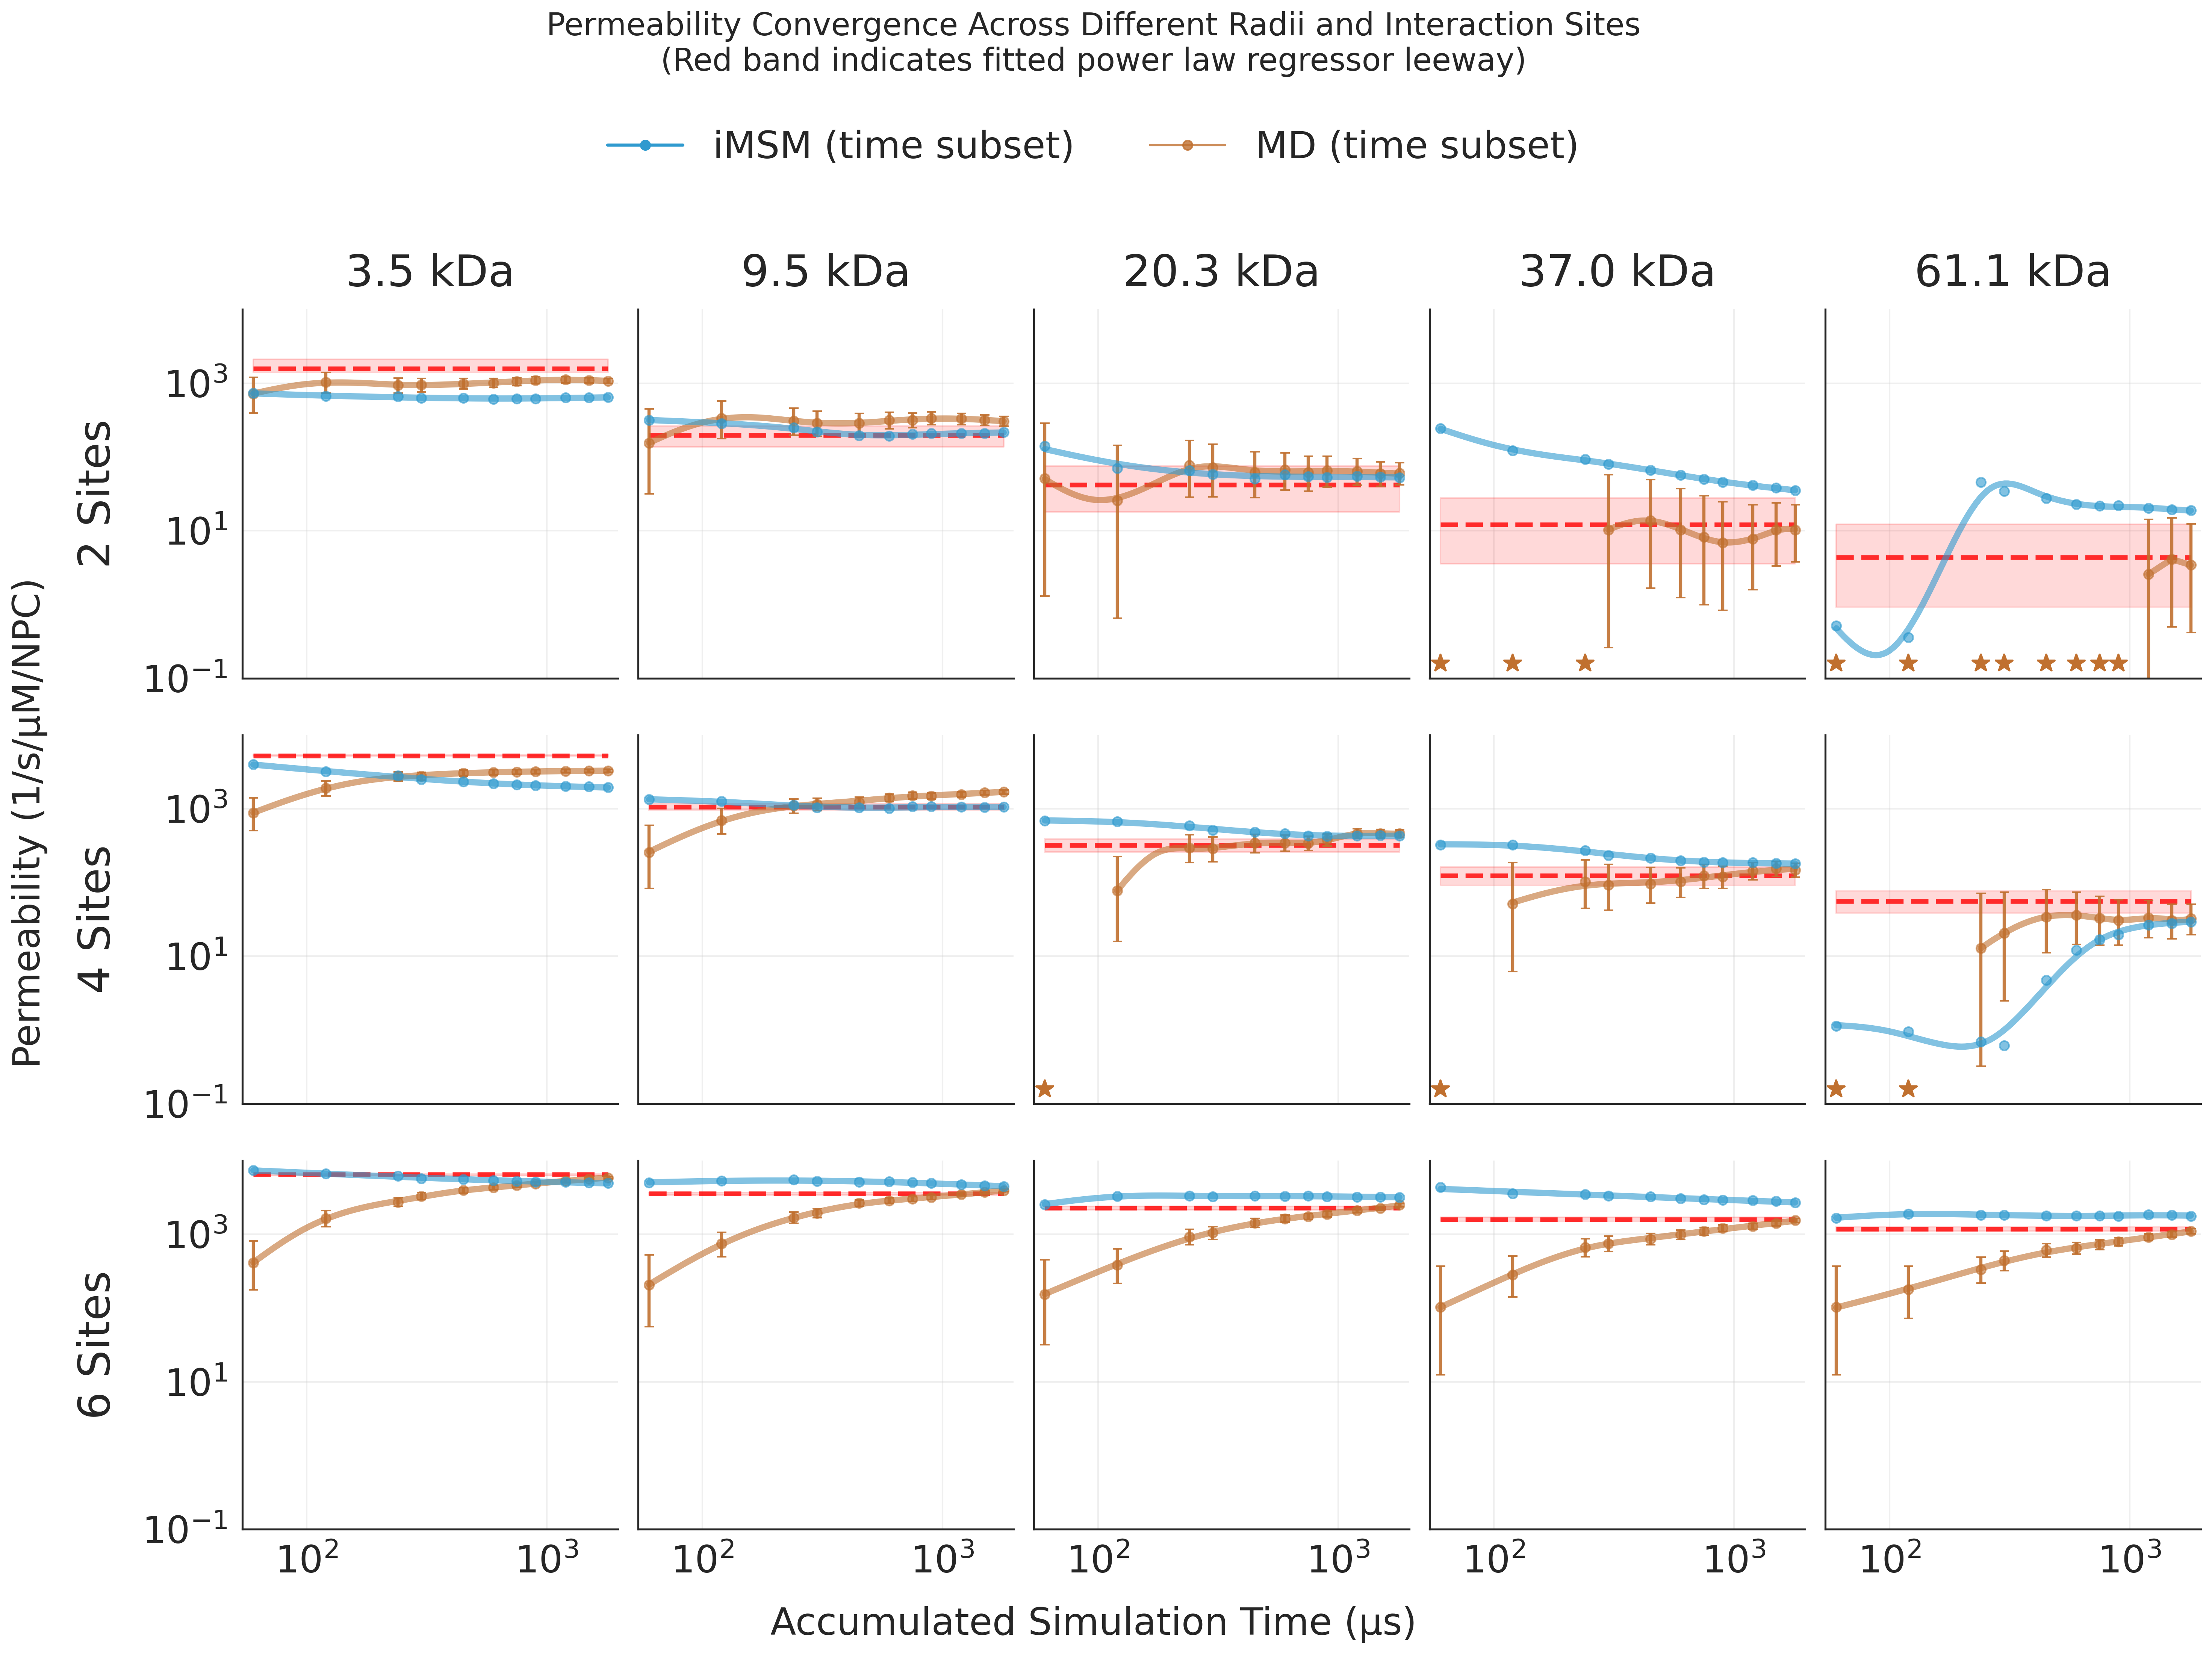

In [28]:
# --- New Boolean Flags ---
include_sim_subset = False  # Set to False to hide the time subset plots
smooth_msm = True           # Set to True to perform cumulative smoothing on MSM data
include_init_time = False

# Helper function for MSM smoothing
def apply_smoothing(data):
    smoothed = np.zeros_like(data)
    for w in range(len(data)):
        smoothed[w] = np.mean(data[: w + 1])
    return smoothed
# -------------------------

fig, axes = plt.subplots(len(sites_list), len(radii), figsize=(20, 15), sharex=True, sharey=True, dpi=300)

labels_for_legend = []
targ_line = None

for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        ax = axes[j, i]
        
        # MD Data
        md_perms = perms_all_md[i, j, :]
        md_lower_perms = lower_perms_all_md[i, j, :]
        md_upper_perms = upper_perms_all_md[i, j, :]
        
        md_perms_sim_subset = perms_all_md_sim_subset[i, j, :]
        md_lower_perms_sim_subset = lower_perms_all_md_sim_subset[i, j, :]
        md_upper_perms_sim_subset = upper_perms_all_md_sim_subset[i, j, :]
        
        # MSM Data
        msm_perms = perms_all_msm[i, j, :]
        msm_perms_init_time = perms_all_msm_with_init_time[i, j, :]
        msm_sim_subset_perms = perms_all_msm_sim_subset[i, j, :]
        
        # Apply smoothing to MSM data if flag is set
        if smooth_msm:
            msm_perms = apply_smoothing(msm_perms)
            msm_perms_init_time = apply_smoothing(msm_perms_init_time)
            msm_sim_subset_perms = apply_smoothing(msm_sim_subset_perms)
            
        div_factor = 1  
        
        # 1. Target "Leeway" Zone
        t_line = plot_target_line(ax, total_simulation_times, sites_to_fitted_perms[sites][i], 
                                 sites_to_fitted_perms_lo[sites][i], sites_to_fitted_perms_hi[sites][i])
        if targ_line is None:
            targ_line = t_line

        # 2. MD Plots
        if include_sim_subset:
            plot_series(ax, np.array(sims_total_simulation_times), md_perms_sim_subset, STYLE['md_sim'], STAR_Y_PERM, md_lower_perms_sim_subset, md_upper_perms_sim_subset, gam_ls='--')


        plot_series(ax, np.array(total_simulation_times), md_perms, STYLE['md_time'], STAR_Y_PERM, md_lower_perms, md_upper_perms)


        # 3. iMSM Plots
        plot_series(ax, np.array(total_simulation_times), msm_perms / div_factor, STYLE['msm_time'], STAR_Y_PERM)
        if include_init_time and sites != 6:
            # We can use a different marker/color for distinction, here we modify the msm_time style slightly
            style_msm_init = STYLE['msm_time'].copy()
            style_msm_init['color'] = '#4daf4a'  # green
            plot_series(ax, np.array(total_simulation_times), msm_perms_init_time / div_factor, style_msm_init, STAR_Y_PERM)
        
        if include_sim_subset:
            plot_series(ax, np.array(sims_total_simulation_times), msm_sim_subset_perms / div_factor, STYLE['msm_sim'], STAR_Y_PERM, gam_ls='--')
        
        # Subplot aesthetics
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        ax.set_xlim(sims_total_simulation_times[0]*0.9, sims_total_simulation_times[-1]*1.1)
        ax.set_ylim(10**-1, 10**4)
        
        ax.tick_params(axis='both', which='major', labelsize=24)
        
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        # Add labels to the left of the leftmost subplots
        if i == 0:
            ax.set_ylabel(f'{sites} Sites', fontsize=28, labelpad=15)
            
        # Add labels to the top of the top-row subplots
        if j == 0:
            ax.set_title(f'{kdas[i]:.1f} kDa', fontsize=28, pad=15)


# 4. Common text and Unified Legend
fig.text(0.5, 0.02, 'Accumulated Simulation Time (μs)', ha='center', fontsize=24)
fig.text(0.02, 0.5, 'Permeability (1/s/µM/NPC)', va='center', rotation='vertical', fontsize=24)

fig.suptitle('Permeability Convergence Across Different Radii and Interaction Sites\n(Red band indicates fitted power law regressor leeway)', 
             fontsize=20, y=0.98)

# Dynamically build the legend based on the boolean flags
custom_lines = []

custom_lines.append(Line2D([0], [0], color=STYLE['msm_time']['color'], marker=STYLE['msm_time']['marker'], linestyle='-', linewidth=2, label='iMSM (time subset)'))
if include_init_time:
    custom_lines.append(Line2D([0], [0], color='#4daf4a', marker=STYLE['msm_time']['marker'], linestyle='-', linewidth=2, label='iMSM (init time)'))

if include_sim_subset:
    custom_lines.append(Line2D([0], [0], color=STYLE['msm_sim']['color'], marker=STYLE['msm_sim']['marker'], linestyle='--', linewidth=2, label='iMSM (sim subset)'))

custom_lines.append(Line2D([0], [0], color=STYLE['md_time']['color'], marker=STYLE['md_time']['marker'], linestyle='-', linewidth=1.5, alpha=0.8, label='MD (time subset)'))

if include_sim_subset:
    custom_lines.extend([
        Line2D([0], [0], color=STYLE['md_sim']['color'], marker=STYLE['md_sim']['marker'], linestyle='--', linewidth=1.5, alpha=0.8, label='MD (sim subset)'),
        targ_line
    ])

# Place one main legend at the top of the figure
ncols = len(custom_lines) // 2 + 1 if len(custom_lines) > 5 else len(custom_lines)
fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
           ncol=ncols, frameon=False, fontsize=24)

# Adjust layout to make room for the new suptitle and top legend
plt.tight_layout(rect=[0.04, 0.04, 1, 0.90])
plt.show()

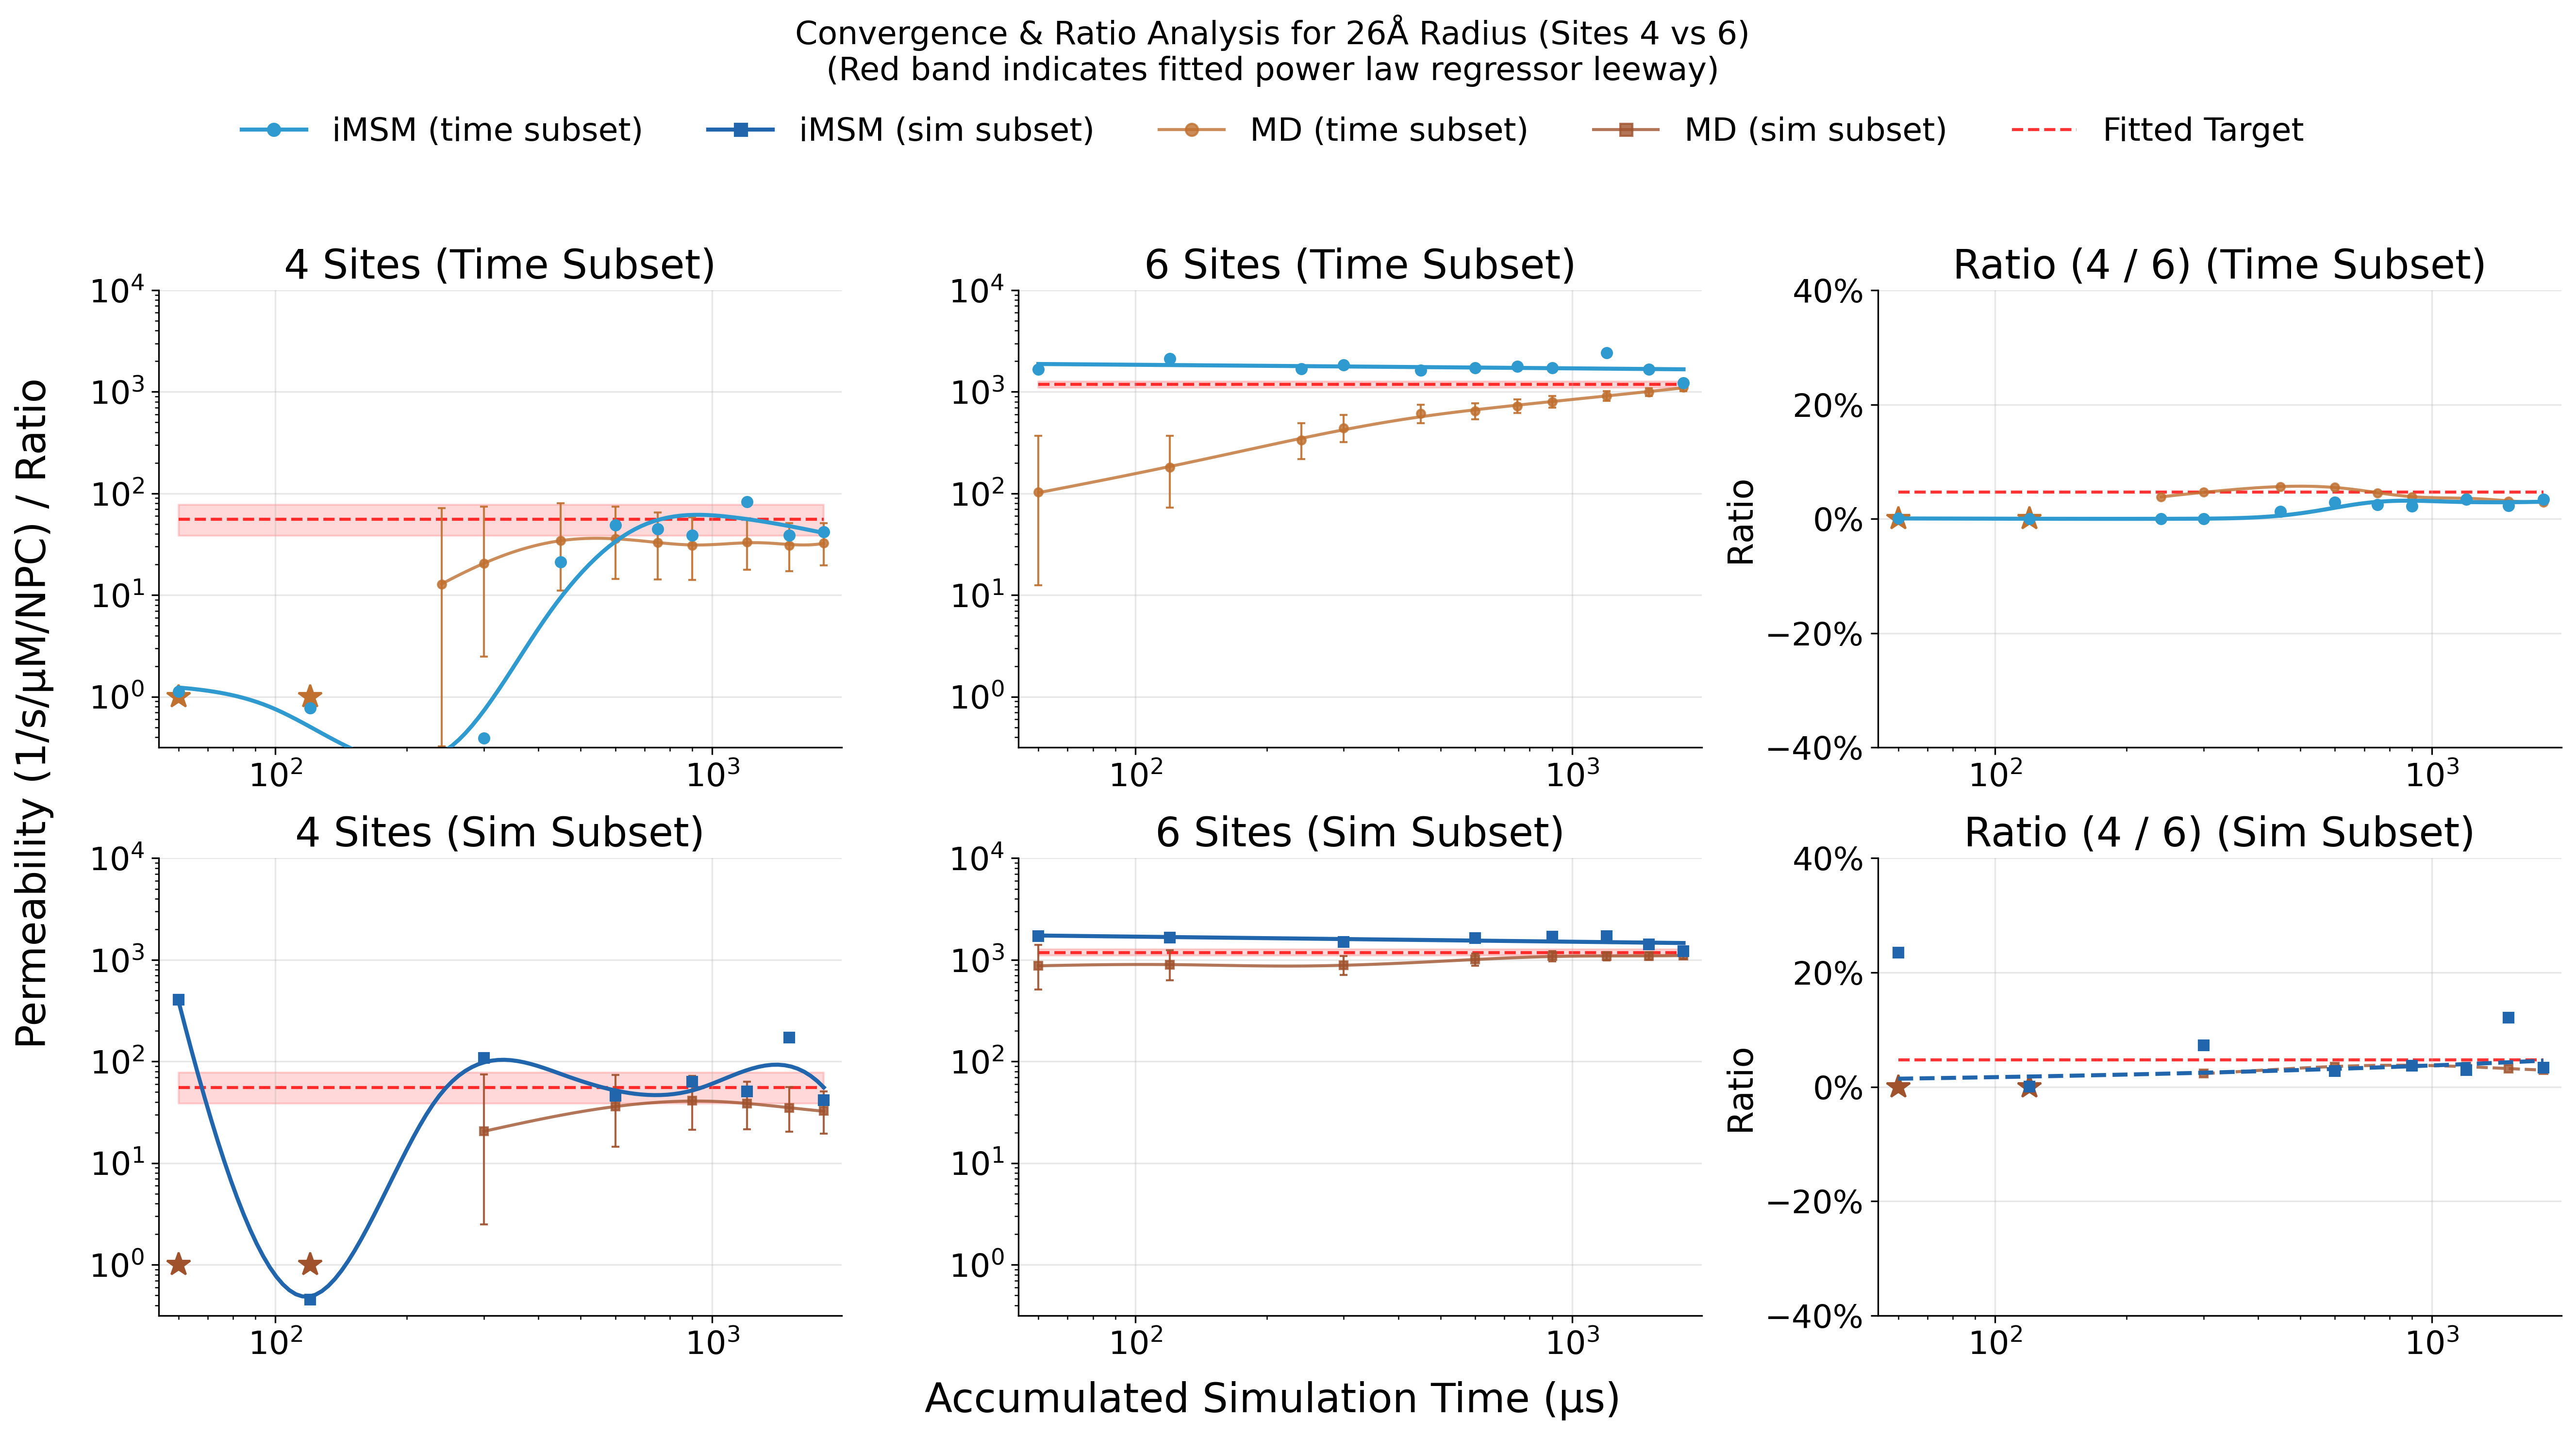

In [7]:
# ==========================================
# CONFIGURATION & MAGIC NUMBERS
# ==========================================
RADIUS_TARGET = 26
SITE_A = 4
SITE_B = 6

STAR_Y_RATIO = 0.0  # Changed for linear scale

AXIS_LIMITS = {
    'perm': (10**-0.5, 10**4),
    'ratio': (-0.4, 0.4)  
}

# ==========================================
# SETUP & DATA EXTRACTION
# ==========================================

r_idx = list(radii).index(RADIUS_TARGET)
s_a_idx = list(sites_list).index(SITE_A)
s_b_idx = list(sites_list).index(SITE_B)

kda_val = kdas[r_idx]
target_ratio = sites_to_fitted_perms[SITE_A][r_idx] / sites_to_fitted_perms[SITE_B][r_idx]

# Define data subsets for the two rows to avoid massive blocks of duplicated code
subsets = [
    {
        'title': 'Time Subset',
        'x': np.array(total_simulation_times),
        'md': perms_all_md,
        'md_lo': lower_perms_all_md,
        'md_hi': upper_perms_all_md,
        'msm': perms_all_msm,
        'style_md': STYLE['md_time'],
        'style_msm': STYLE['msm_time'],
        'ratio_ls': '-'
    },
    {
        'title': 'Sim Subset',
        'x': np.array(sims_total_simulation_times),
        'md': perms_all_md_sim_subset,
        'md_lo': lower_perms_all_md_sim_subset,
        'md_hi': upper_perms_all_md_sim_subset,
        'msm': perms_all_msm_sim_subset,
        'style_md': STYLE['md_sim'],
        'style_msm': STYLE['msm_sim'],
        'ratio_ls': '--'
    }
]

# ==========================================
# MAIN PLOTTING LOOP
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
targ_line = None  # Reference for the legend

for i, sub in enumerate(subsets):
    x = sub['x']
    title_suffix = f"({sub['title']})"
    
    # Data extraction for this specific row
    md_a, msm_a = sub['md'][r_idx, s_a_idx, :], sub['msm'][r_idx, s_a_idx, :]
    md_b, msm_b = sub['md'][r_idx, s_b_idx, :], sub['msm'][r_idx, s_b_idx, :]
    
    # --- Panel 1: Site A ---
    ax = axes[i, 0]
    targ_line = plot_target_line(ax, x, sites_to_fitted_perms[SITE_A][r_idx], 
                                 sites_to_fitted_perms_lo[SITE_A][r_idx], sites_to_fitted_perms_hi[SITE_A][r_idx])
    plot_series(ax, x, md_a, sub['style_md'], 1, sub['md_lo'][r_idx, s_a_idx, :], sub['md_hi'][r_idx, s_a_idx, :])
    plot_series(ax, x, msm_a, sub['style_msm'], 1)
    ax.set_title(f'{SITE_A} Sites {title_suffix}', fontsize=20)
    
    # --- Panel 2: Site B ---
    ax = axes[i, 1]
    plot_target_line(ax, x, sites_to_fitted_perms[SITE_B][r_idx], 
                     sites_to_fitted_perms_lo[SITE_B][r_idx], sites_to_fitted_perms_hi[SITE_B][r_idx])
    plot_series(ax, x, md_b, sub['style_md'], 1, sub['md_lo'][r_idx, s_b_idx, :], sub['md_hi'][r_idx, s_b_idx, :])
    plot_series(ax, x, msm_b, sub['style_msm'], 1)
    ax.set_title(f'{SITE_B} Sites {title_suffix}', fontsize=20)
    
    # --- Panel 3: Ratio (A / B) ---
    ax = axes[i, 2]
    plot_target_line(ax, x, target_ratio)
    plot_series(ax, x, get_ratio(md_a, md_b), sub['style_md'], STAR_Y_RATIO, gam_ls=sub['ratio_ls'])
    plot_series(ax, x, get_ratio(msm_a, msm_b), sub['style_msm'], STAR_Y_RATIO, gam_ls=sub['ratio_ls'])
    
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(f'Ratio ({SITE_A} / {SITE_B}) {title_suffix}', fontsize=20)
    ax.set_ylabel('Ratio', fontsize=17)

# ==========================================
# AESTHETICS & LAYOUT
# ==========================================

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        
        # Apply conditional formatting depending on if it's a Ratio panel (j==2)
        if j == 2:
            ax.set_yscale('linear')
            ax.set_ylim(AXIS_LIMITS['ratio'])
            # Format the y-axis to show percentages
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
        else:
            ax.set_yscale('log')
            ax.set_ylim(AXIS_LIMITS['perm'])
            
        ax.set_xlim(subsets[i]['x'][0]*0.9, subsets[i]['x'][-1]*1.1)
            
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Common text and Unified Legend
fig.text(0.5, 0.02, 'Accumulated Simulation Time (μs)', ha='center', fontsize=20)
fig.text(0.02, 0.5, 'Permeability (1/s/µM/NPC) / Ratio', va='center', rotation='vertical', fontsize=20)
fig.suptitle(f'Convergence & Ratio Analysis for {RADIUS_TARGET}Å Radius (Sites {SITE_A} vs {SITE_B})\n(Red band indicates fitted power law regressor leeway)', 
             fontsize=16, y=0.98)

custom_lines = [
    Line2D([0], [0], color=STYLE['msm_time']['color'], marker=STYLE['msm_time']['marker'], linestyle='-', linewidth=2, label='iMSM (time subset)'),
    Line2D([0], [0], color=STYLE['msm_sim']['color'], marker=STYLE['msm_sim']['marker'], linestyle='-', linewidth=2, label='iMSM (sim subset)'),
    Line2D([0], [0], color=STYLE['md_time']['color'], marker=STYLE['md_time']['marker'], linestyle='-', linewidth=1.5, alpha=0.8, label='MD (time subset)'),
    Line2D([0], [0], color=STYLE['md_sim']['color'], marker=STYLE['md_sim']['marker'], linestyle='-', linewidth=1.5, alpha=0.8, label='MD (sim subset)'),
    targ_line
]

fig.legend(handles=custom_lines, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=5, frameon=False, fontsize=16)

plt.tight_layout(rect=[0.04, 0.04, 1, 0.90])
plt.show()


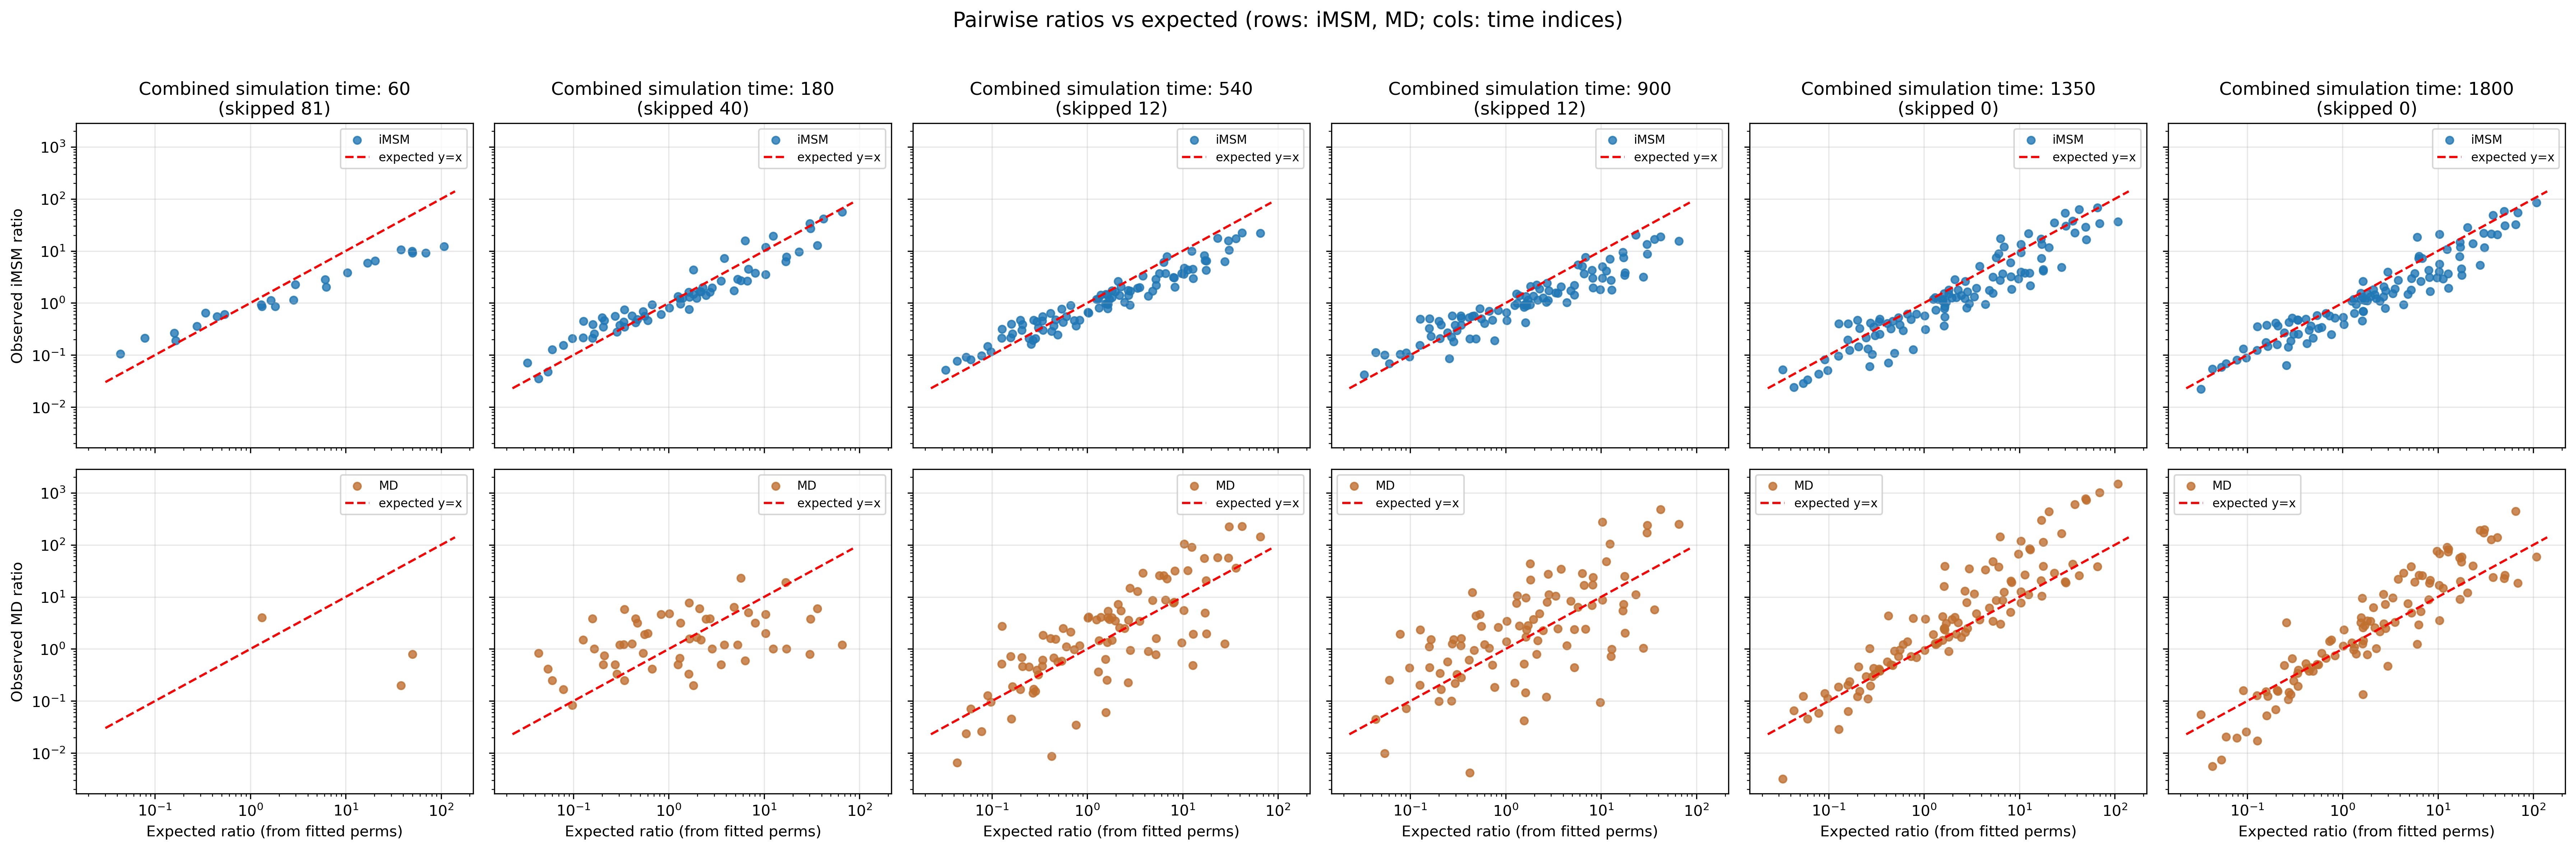

In [9]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# pick up to 5 evenly spaced time indices across the trajectory
max_cols = 6
time_indices = np.linspace(
    0, perms_all_msm.shape[2] - 1,
    num=min(max_cols, perms_all_msm.shape[2]),
    dtype=int
)

combos = [(i, j) for i in range(len(radii)) for j in range(len(sites_list))]

def expected_ratio(i1, j1, i2, j2):
    num = sites_to_fitted_perms[sites_list[j1]][i1]
    den = sites_to_fitted_perms[sites_list[j2]][i2]
    if den == 0:
        return None
    return num / den

fig, axes = plt.subplots(2, len(time_indices), figsize=(4*len(time_indices), 8), dpi=300, sharex=True, sharey=True)

for col, t_idx in enumerate(time_indices):
    # collect ratios
    exp_vals = []
    msm_vals = []
    md_vals = []
    skipped = 0

    for (i1, j1), (i2, j2) in itertools.combinations(combos, 2):
        exp_r = expected_ratio(i1, j1, i2, j2)
        if exp_r is None or exp_r == 0:
            skipped += 1
            continue

        # observed ratios; skip if denominator is zero
        msm_den = perms_all_msm[i2, j2, t_idx]
        md_den = perms_all_md[i2, j2, t_idx]
        if msm_den == 0 or md_den == 0:
            skipped += 1
            continue

        msm_r = perms_all_msm[i1, j1, t_idx] / msm_den
        md_r = perms_all_md[i1, j1, t_idx] / md_den

        exp_vals.append(exp_r)
        msm_vals.append(msm_r)
        md_vals.append(md_r)

    exp_vals = np.array(exp_vals)
    msm_vals = np.array(msm_vals)
    md_vals = np.array(md_vals)

    # row 0: iMSM vs expected
    ax0 = axes[0, col] if axes.ndim == 2 else axes[col]
    ax0.scatter(exp_vals, msm_vals, alpha=0.8, s=25, label='iMSM')
    xline = np.logspace(np.log10(exp_vals.min()*0.7), np.log10(exp_vals.max()*1.3), 200)
    ax0.plot(xline, xline, color='red', ls='--', lw=1.5, label='expected y=x')
    ax0.set_xscale('log')
    ax0.set_yscale('log')
    ax0.set_title(f"Combined simulation time: {total_simulation_times[t_idx]}\n(skipped {skipped})")
    ax0.grid(True, alpha=0.3)
    if col == 0:
        ax0.set_ylabel("Observed iMSM ratio")
    ax0.legend(fontsize=8)

    # row 1: MD vs expected
    ax1 = axes[1, col] if axes.ndim == 2 else axes[col]
    ax1.scatter(exp_vals, md_vals, alpha=0.8, s=25, color="#c0702f", label='MD')
    ax1.plot(xline, xline, color='red', ls='--', lw=1.5, label='expected y=x')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    if col == 0:
        ax1.set_ylabel("Observed MD ratio")
    ax1.set_xlabel("Expected ratio (from fitted perms)")
    ax1.legend(fontsize=8)

plt.suptitle("Pairwise ratios vs expected (rows: iMSM, MD; cols: time indices)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

[ 102.77786897  282.63913967  668.05614831  750.27844349  863.33409935
  986.66754212 1101.77875537 1209.35292489 1284.72336213 1408.0568049
 1541.66803456]
MD convergence time: 450.0 μs
[4337.30985648 3556.10477041 3483.44398237 3333.0250149  3232.97273684
 3073.80882127 2969.80485587 2905.39431278 2879.02399469 2832.14272215
 2703.21580629]
iMSM convergence time: 60.0 μs


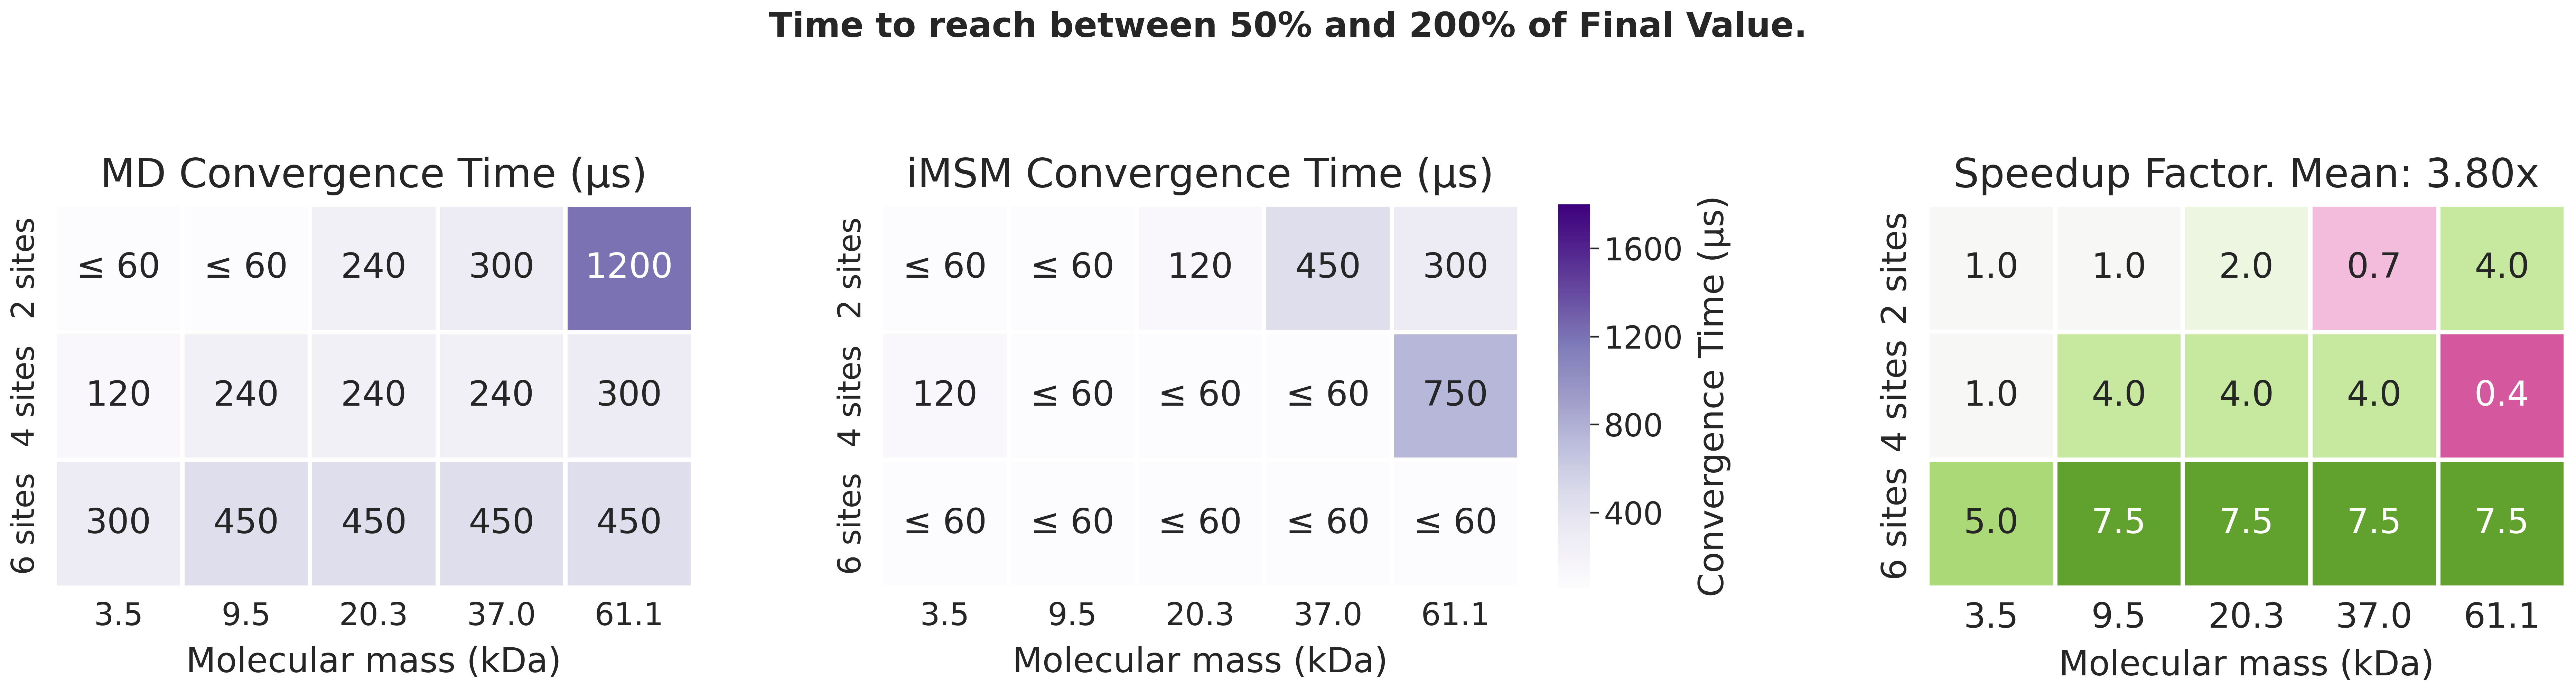

In [25]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker 

# Ensure clean white background style for premium plots
sns.set_theme(style='white')

# ----------------- Data Processing (Preserved) -----------------
use_sim_subset = False
min_convergence_factor = 0.5
max_convergence_factor = 2

md_convergences = np.zeros((len(radii), len(sites_list)))
msm_convergences = np.zeros((len(radii), len(sites_list)))

for i, radius in enumerate(radii):
    for j, sites in enumerate(sites_list):
        if use_sim_subset:
            md_perms = perms_all_md_sim_subset[i, j, :]
            msm_perms = perms_all_msm_sim_subset[i, j, :]
        else:
            md_perms = perms_all_md[i, j, :]
            msm_perms = perms_all_msm[i, j, :]
        
        md_perms_smooth = md_perms
        msm_perms_smooth = np.zeros_like(msm_perms)
        
        for w in range(len(md_perms)):
            msm_perms_smooth[w] = np.mean(msm_perms[: w + 1])
        
        final_md_perm = md_perms_smooth[-1]
        final_msm_perm = msm_perms_smooth[-1]
        
        for k in range(len(subsets)):
            if np.all(md_perms_smooth[k:] >= min_convergence_factor * final_md_perm) and \
               np.all(md_perms_smooth[k:] <= max_convergence_factor * final_md_perm):
                md_convergences[i, j] = total_simulation_times[k]
                break
                
        for k in range(len(subsets)):
            if np.all(msm_perms_smooth[k:] >= min_convergence_factor * final_msm_perm) and \
               np.all(msm_perms_smooth[k:] <= max_convergence_factor * final_msm_perm):
                msm_convergences[i, j] = total_simulation_times[k]
                break
            
        if (sites == 6 and radius == 22):
            print(md_perms_smooth)
            print(f"MD convergence time: {md_convergences[i, j]} μs")
            print(msm_perms_smooth)
            print(f"iMSM convergence time: {msm_convergences[i, j]} μs")

min_convergence_time = 60
max_convergence_time = 1800

def format_val(v):
    if np.isnan(v) or v == 0:
        return ""
    if v >= max_convergence_time:
        return f"\u2265 {max_convergence_time}"
    if v <= min_convergence_time:
        return f"\u2264 {min_convergence_time}"
    return f"{v:.0f}"

md_convergences_t = md_convergences.T
msm_convergences_t = msm_convergences.T
speedup_factor_t = (md_convergences / msm_convergences).T

md_labels = np.vectorize(format_val)(md_convergences_t)
msm_labels = np.vectorize(format_val)(msm_convergences_t)

# Define custom row labels based on the interaction sites
row_labels = [f"{s} sites" for s in sites_list]

# ----------------- Visualizations & Layout Improvements -----------------
# 1. We define 4 subplots (3 heatmaps and 1 dedicated colorbar axes).
#    By using a custom width ratio for the colorbar, we prevent matplotlib 
#    from stealing space from the second heatmap, making all three heatmaps 
#    the exact same size.
fig, axes = plt.subplots(
    nrows=1, 
    ncols=4, 
    figsize=(25, 7), 
    gridspec_kw={'width_ratios': [1.0, 1.0, 0.05, 1.0]}, 
    dpi=300
)

# 2. Main suptitle with premium size and bold styling
fig.suptitle(
    'Time to reach between 50% and 200% of Final Value.', 
    fontsize=24, 
    y=0.995, 
    weight='bold'
)

# ----------------- MD heatmap (Axis 0) -----------------
im0 = sns.heatmap(
    md_convergences_t, 
    annot=md_labels, 
    fmt='', 
    cmap='Purples', 
    ax=axes[0], 
    cbar=False, 
    square=True,
    vmin=min_convergence_time, 
    vmax=max_convergence_time, 
    annot_kws={"size": 24},
    linewidth=3
)
axes[0].set_xticklabels([f"{kda:.1f}" for kda in kdas], fontsize=21.6)
axes[0].set_yticklabels(row_labels, rotation=90, va='center', ha='right', fontsize=21.6)
axes[0].set_xlabel('Molecular mass (kDa)', fontsize=24, labelpad=10)
axes[0].set_ylabel('')
axes[0].set_title('MD Convergence Time (μs)', fontsize=28, pad=12)

# ----------------- MSM heatmap (Axis 1) -----------------
# We pass the third axes (axes[2]) as cbar_ax to keep axes[1] square and correctly sized
im1 = sns.heatmap(
    msm_convergences_t, 
    annot=msm_labels, 
    fmt='', 
    cmap='Purples', 
    ax=axes[1], 
    cbar=True, 
    cbar_ax=axes[2],
    square=True,
    vmin=min_convergence_time, 
    vmax=max_convergence_time, 
    annot_kws={"size": 24},
    linewidth=3
)
axes[1].set_xticklabels([f"{kda:.1f}" for kda in kdas], fontsize=21.6)
axes[1].set_yticklabels(row_labels, rotation=90, va='center', ha='right', fontsize=21.6)
axes[1].set_xlabel('Molecular mass (kDa)', fontsize=24, labelpad=10)
axes[1].set_ylabel('')
axes[1].set_title('iMSM Convergence Time (μs)', fontsize=28, pad=12)
# Style the shared purple colorbar in axes[2]
cbar1 = im1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=21.6)
cbar1.set_label('Convergence Time (μs)', size=24, labelpad=10)
# <-- 2. Reduce tick density (change nbins to get more or fewer ticks)
cbar1.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5)) 

# ------------ Speedup factor heatmap (Axis 3) ------------
v_min = 0.1
v_max = 10.0
norm = mcolors.TwoSlopeNorm(vmin=v_min, vcenter=1.0, vmax=v_max)

im2 = sns.heatmap(
    speedup_factor_t, 
    annot=True, 
    fmt='.1f', 
    cmap='PiYG', 
    norm=norm,  
    ax=axes[3], 
    square=True, 
    annot_kws={"size": 24},
    cbar=False,
    linewidth=3
)

axes[3].set_xticklabels([f"{kda:.1f}" for kda in kdas], fontsize=24)
axes[3].set_yticklabels(row_labels, rotation=90, va='center', ha='right', fontsize=24)
axes[3].set_xlabel('Molecular mass (kDa)', fontsize=24, labelpad=10)
axes[3].set_ylabel('')
axes[3].set_title(
    f'Speedup Factor. Mean: {np.mean(md_convergences / msm_convergences):.2f}x', 
    fontsize=28, 
    pad=12
)

# Render layout nicely with adjusted horizontal pad
plt.tight_layout(w_pad=0.0)
# <-- 3. Align colorbar height and adjust distance to the heatmap
pos1 = axes[1].get_position()  # Position of the square MSM heatmap
pos2 = axes[2].get_position()  # Position of the colorbar
# Gap controls the horizontal distance from the MSM heatmap to the colorbar.
# - Decrease it (e.g. 0.01) to bring the colorbar closer to the left.
# - Increase it (e.g. 0.03) to move it further to the right.
gap = 0.015 
axes[2].set_position([pos1.x1 + gap, pos1.y0, pos2.width, pos1.height])

plt.show()


/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)
/tmp/ipykernel_94915/639002914.py:146: RuntimeWarning: divide by zero encountered in log10
  coeffs = np.polyfit(np.log10(x), np.log10(y), deg=1, w=weights)


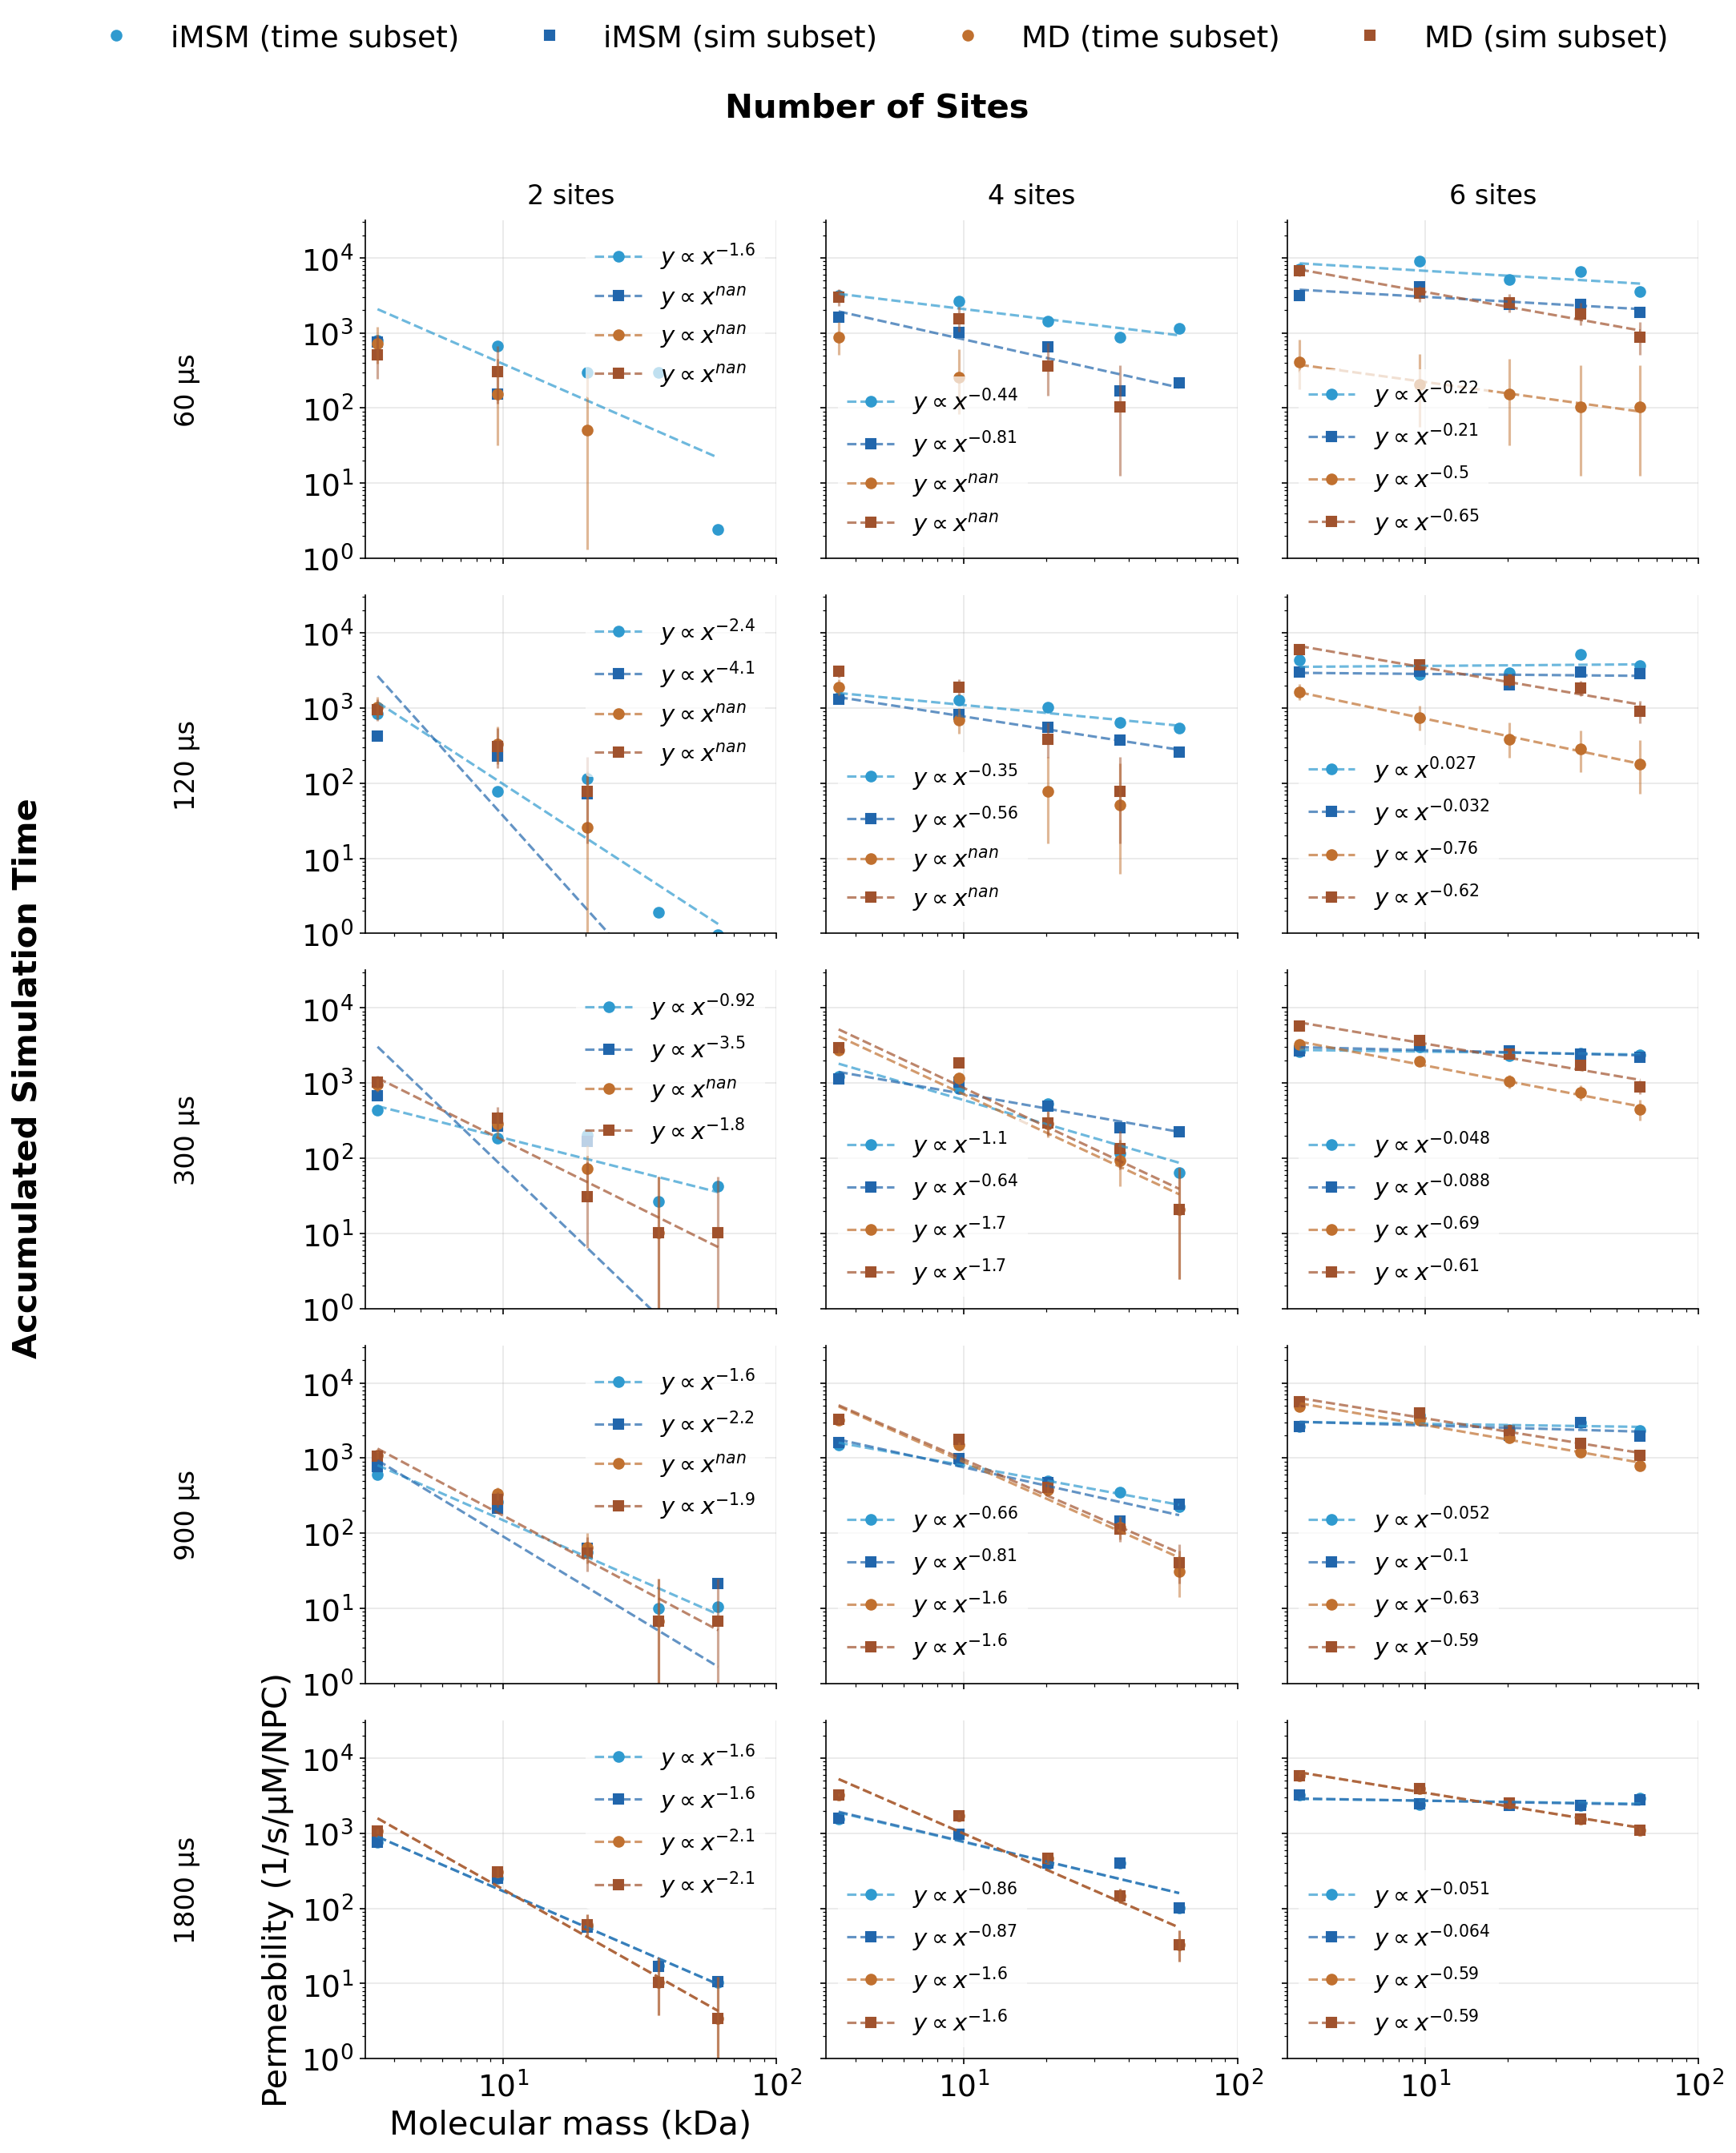

In [37]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, len(sites_list), figsize=(15, 20), sharex=True, sharey=True, dpi=150)

indexes_for_time_sites_fig = []
indexes_sim_for_time_sites_fig = []
subset_sizes_for_time_sites_fig = [2/60, 4/60, 10/60, 30/60, 1.0]

for target in subset_sizes_for_time_sites_fig:
    # not exact
    idx = np.argmin(np.abs(np.array(subsets) - target))
    indexes_for_time_sites_fig.append(idx)
    idx = np.argmin(np.abs(np.array(sims_subsets) - target))
    indexes_sim_for_time_sites_fig.append(idx)

# We will grab the handles for a unified legend later
lines_for_legend = []
labels_for_legend = []

for plt_idx, (i_time_sub, i_sim_sub) in enumerate(zip(indexes_for_time_sites_fig, indexes_sim_for_time_sites_fig)):
    # Calculate accumulated simulation time for the row label
    accumulated_time = subset_sizes_for_time_sites_fig[plt_idx] * 1800
    
    for j, sites in enumerate(sites_list):
        ax = axes[plt_idx, j]
        md_perms = perms_all_md[:, j, i_time_sub]
        md_lower_perms = lower_perms_all_md[:, j, i_time_sub]
        md_upper_perms = upper_perms_all_md[:, j, i_time_sub]
        
        md_perms_sim_subset = perms_all_md_sim_subset[:, j, i_sim_sub]
        md_lower_perms_sim_subset = lower_perms_all_md_sim_subset[:, j, i_sim_sub]
        md_upper_perms_sim_subset = upper_perms_all_md_sim_subset[:, j, i_sim_sub]
        
        msm_perms = perms_all_msm[:, j, i_time_sub]
        msm_sim_subset_perms = perms_all_msm_sim_subset[:, j, i_sim_sub]
        div_factor = 1  # single free parameter
        
        # 1. Plot unconnected scatter dots (linestyle='None') - Saving handles directly
        msm_time_scat, = ax.plot(kdas, msm_perms / div_factor, marker='o', linestyle='None', color="#2f9acf")
        msm_sim_scat,  = ax.plot(kdas, msm_sim_subset_perms / div_factor, marker='s', linestyle='None', color="#2166ac")
        md_time_scat,  = ax.plot(kdas, md_perms, marker='o', linestyle='None', color="#c0702f")
        md_sim_scat,   = ax.plot(kdas, md_perms_sim_subset, marker='s', linestyle='None', color="#a0522d")
        
        # 2. Calculate and plot power law fits - Saving handles directly
        x_fit, y_fit, a_msm_time, b_msm_time, _ = weighted_power_law_fit(kdas, msm_perms / div_factor, None)
        msm_time_line, = ax.plot(x_fit, y_fit, linestyle='--', color="#2f9acf", alpha=0.7)

        x_fit, y_fit, a_msm_sim, b_msm_sim, _ = weighted_power_law_fit(kdas, msm_sim_subset_perms / div_factor, None)
        msm_sim_line, = ax.plot(x_fit, y_fit, linestyle='--', color="#2166ac", alpha=0.7)

        x_fit, y_fit, a_md_time, b_md_time, _ = weighted_power_law_fit(kdas, md_perms, None)
        md_time_line, = ax.plot(x_fit, y_fit, linestyle='--', color="#c0702f", alpha=0.7)

        x_fit, y_fit, a_md_sim, b_md_sim, _ = weighted_power_law_fit(kdas, md_perms_sim_subset, None)
        md_sim_line, = ax.plot(x_fit, y_fit, linestyle='--', color="#a0522d", alpha=0.7)

        # 3. Create the inner legend
        # Combine handles into tuples so matplotlib plots both the scatter point AND the line
        combined_handles = [
            (msm_time_scat, msm_time_line),
            (msm_sim_scat, msm_sim_line),
            (md_time_scat, md_time_line),
            (md_sim_scat, md_sim_line)
        ]
        
        # Determine if this is the top left plot
        is_top_left = (plt_idx == 0) and (j == 0)
        
        # if is_top_left:
        #     combined_labels = [
        #         fr"iMSM (time): $y \propto x^{{{a_msm_time:.2g}}}$",
        #         fr"iMSM (sim): $y \propto x^{{{a_msm_sim:.2g}}}$",
        #         fr"MD (time): $y \propto x^{{{a_md_time:.2g}}}$",
        #         fr"MD (sim): $y \propto x^{{{a_md_sim:.2g}}}$"
        #     ]
        # else:
        combined_labels = [
            fr"$y \propto x^{{{a_msm_time:.2g}}}$",
            fr"$y \propto x^{{{a_msm_sim:.2g}}}$",
            fr"$y \propto x^{{{a_md_time:.2g}}}$",
            fr"$y \propto x^{{{a_md_sim:.2g}}}$"
        ]
        
        # Left plots (j == 0) get 'upper right', everything else gets 'lower left'
        leg_loc = 'upper right' if j == 0 else 'lower left'
        
        # Increased fontsize from 12 to 14
        ax.legend(combined_handles, combined_labels, loc=leg_loc, fontsize=14, 
                  framealpha=0.7, edgecolor='none')

        # 4. Error bars
        ax.errorbar(
            kdas, md_perms,
            yerr=[np.array(md_perms) - np.array(md_lower_perms), np.array(md_upper_perms) - np.array(md_perms)],
            fmt='none', ecolor="#c0702f", alpha=0.5
        )
        ax.errorbar(
            kdas, md_perms_sim_subset,
            yerr=[np.array(md_perms_sim_subset) - np.array(md_lower_perms_sim_subset), np.array(md_upper_perms_sim_subset) - np.array(md_perms_sim_subset)],
            fmt='none', ecolor="#a0522d", alpha=0.5
        )
        
        # --- Ticks, Grid, and Scales ---
        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.grid(True, alpha=0.3)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xticks([10**1, 10**2])
        ax.set_xticklabels([fr"$10^1$", fr"$10^2$"])
        
        ax.set_xlim(kdas[0]*0.9, 10**2)
        ax.set_ylim(1, 10**4.5)
        
        # --- GRID LABELS ---
        if plt_idx == 0:
            ax.set_title(f'{sites} sites', fontsize=16, pad=10)
            
        if j == 0:
            ax.text(-0.4, 0.5, f'{accumulated_time:.0f} µs', transform=ax.transAxes,
                    rotation=90, va='center', ha='right', fontsize=16)
        
        # Grab legend info only from the first subplot to avoid duplicates for the MAIN outer legend
        if plt_idx == 0 and j == 0:
            lines_for_legend = [msm_time_scat, msm_sim_scat, md_time_scat, md_sim_scat]
            labels_for_legend = ['iMSM (time subset)', 'iMSM (sim subset)', 'MD (time subset)', 'MD (sim subset)']
        
        # Hide top and right spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        

# --- INNER AXES LABELS (Bottom Left Plot Only) ---
axes[-1, 0].set_xlabel('Molecular mass (kDa)', fontsize=20)
axes[-1, 0].set_ylabel('Permeability (1/s/µM/NPC)', fontsize=20)

# --- BIG OUTER AXES LABELS (For the grid dimensions) ---
fig.text(0.5, 0.90, 'Number of Sites', ha='center', fontsize=20, fontweight='bold')
fig.text(0.02, 0.5, 'Accumulated Simulation Time', va='center', rotation=90, fontsize=20, fontweight='bold')

# Place one main legend at the top of the figure (for the scatter points)
fig.legend(lines_for_legend, labels_for_legend, loc='upper center', bbox_to_anchor=(0.5, 0.95), 
           ncol=4, frameon=False, fontsize=18)

plt.tight_layout(rect=[0.10, 0.05, 0.98, 0.88])
plt.show()

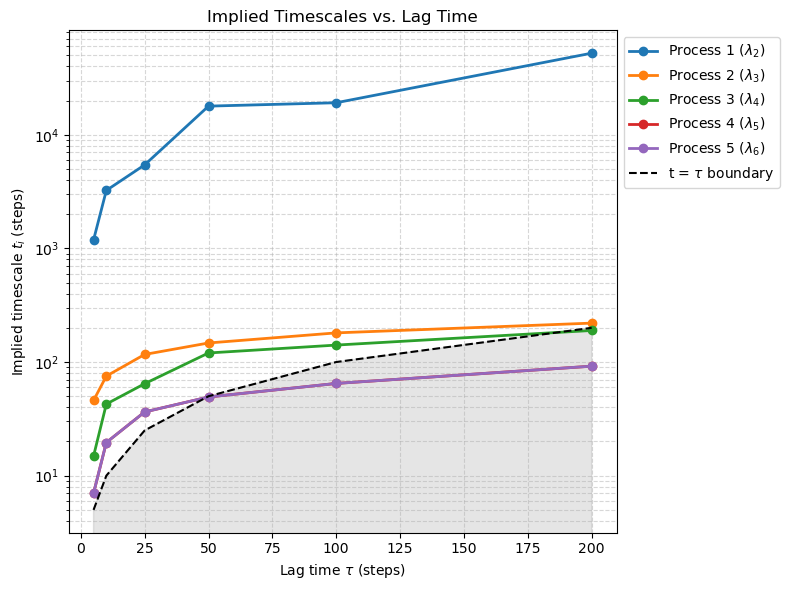

In [ ]:
n_top_eigenvalues = 5

timescales = []
for i in range(n_top_eigenvalues):
    timescales.append([])
    
for window_size_steps in [5, 10, 25, 50, 100, 200]: 
    with open(f"data/ntr_variants_4_26_timescales/window_{window_size_steps}_steps/6_transition_matrices_subsets/1.00fraction_simulations/0index/160clusters.pickle", "rb") as f:
        tm = pickle.load(f)
        
    # 1. Compute the eigenvalues of the transition matrix
    eigenvalues = np.linalg.eigvals(tm)
    
    # 2. Sort the eigenvalues by absolute magnitude in descending order
    sorted_eigenvalues = np.sort(np.abs(eigenvalues))[::-1]
    
    # 3. Compute the implied timescales
    for i in range(n_top_eigenvalues):
        # We use i + 1 to skip the 0th eigenvalue (which is ~1.0 for the stationary distribution)
        lambda_i = sorted_eigenvalues[i + 1]
        
        # Catch numerical instability edge-cases (lambda should be strictly between 0 and 1)
        if lambda_i >= 1.0 or lambda_i <= 0.0:
            t_i = np.nan
        else:
            # Apply the formula: t_i = -tau / ln|lambda_i|
            t_i = -window_size_steps / np.log(lambda_i)
            
        timescales[i].append(t_i)
        
# Plotting
# The lag times used in your loop
lag_times = [5, 10, 25, 50, 100, 200]

plt.figure(figsize=(8, 6))

# Plot each of the computed timescales
for i in range(n_top_eigenvalues):
    plt.plot(lag_times, timescales[i], marker='o', linewidth=2, label=f'Process {i+1} ($\lambda_{i+2}$)')

# Plot the t = tau boundary
plt.plot(lag_times, lag_times, color='black', linestyle='--', label='t = $\\tau$ boundary')
plt.fill_between(lag_times, 0, lag_times, color='grey', alpha=0.2)

# Standard ITS plots use a logarithmic y-axis
plt.yscale('log')

# Formatting
plt.xlabel('Lag time $\\tau$ (steps)')
plt.ylabel('Implied timescale $t_i$ (steps)')
plt.title('Implied Timescales vs. Lag Time')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()

# Display the plot
plt.show()